In [2]:
import numpy as np
import pandas as pd
import monaco as mc
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


from functools import reduce

from utils import prophet_fit_predict_elc, monte_opex, monte_capex,prophet_fit_predict_water,\
                        prophet_fit_predict_3_years_after_war, prophet_fit_predict_elc_rest, invest_cost, deconstruction_cost, end_of_life_cost, \
                        operation_cost, life_cycle_cost_of_h2, levelized_cost_of_h2, monte_lcc, monte_pem_capex_5mw_soa

from data import data_elc, water_data, data_nw_elc

In [2]:
# Number of decimal places for Pandas output
pd.options.display.float_format = '{:20,.3f}'.format

In [3]:
# CAPEX - material cost for 5 MW PEM

# Feed material data and corresponding price in
# Material type
material = ['Stainless steel', 'Copper', 'Titanium', 'Platin', 'Iridium', 'Carbon Paper', 'Nafion N117', 'FKM',\
            'Stack Cooling Heat Exchanger', 'Condenser', 'Gas Water Separators', 'Dry Cooler', 'Power Cable',\
            'Data Cable', 'Pumps', 'Inverter', 'Control Unit', 'Housing', 'Foundation']
# Set the corresponding amount for material type            
amount = [625, 68, 3987, 0.67, 9.86, 329, 88.54, 1,\
          1, 1, 2, 1, 50,\
          2000, 6, 1, 1, 2, 4.5]
# Set the unit for material type
material_unit = ['kg']*5
material_unit.extend(['pcs'])
material_unit.extend(['m2'])
material_unit.extend(['pcs']*5)
material_unit.extend(['m']*2)
material_unit.extend(['pcs']*4)
material_unit.extend(['m3'])

# Cooresponding single price
price = [0.78, 6.7, 6.11, 27242.65, 87781.85, 80.62, 6288, 796.36,\
         48000, 42000, 2480.77, 1594.78, 92,\
         0.78, 9300, 320699, 6600, 4950, 181]
# Set the unit for price
material_unit = ['kg']*5
material_unit.extend(['pcs'])
material_unit.extend(['m2'])
material_unit.extend(['pcs']*5)
material_unit.extend(['m']*2)
material_unit.extend(['pcs']*4)
material_unit.extend(['m3'])

single_price_unit = ['€/kg']*5
single_price_unit.extend(['€/pcs'])
single_price_unit.extend(['€/m2'])
single_price_unit.extend(['€/pcs']*5)
single_price_unit.extend(['€/m']*2)
single_price_unit.extend(['€/pcs']*4)
single_price_unit.extend(['€/m3'])

price_unit = ['€']*19

# Use pandas to orgnize the data and provide the names of the categories in the table
df = pd.DataFrame({'Material and Component' : material, 
                   'Amount':  amount,
                   'Unit' : material_unit,
                   'Single Price': price,
                   'Sigle Price Unit': single_price_unit,
                   'Price Unit': price_unit
                    })

# Calculate price based on amount and single price
df.insert(5, 'Price', [a*b for a, b in zip(df['Amount'], df['Single Price'])])

# calculate total price of every material
df = df.append({'Price': df['Price'].sum()}, ignore_index=True)

# add name of row in table (Total)
as_list = df.index.tolist()
as_list[-1] = 'Total'
df.index = as_list

df.fillna('', inplace=True)

df.head(22)

WARNING - (py.warnings._showwarnmsg) - C:\Users\yc20\AppData\Local\Temp\ipykernel_11288\704716177.py:57: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({'Price': df['Price'].sum()}, ignore_index=True)



,Material and Component,Amount,Unit,Single Price,Sigle Price Unit,Price,Price Unit
0,Stainless steel,625.000,kg,0.780,€/kg,487.500,€
1,Copper,68.000,kg,6.700,€/kg,455.600,€
2,Titanium,"3,987.000",kg,6.110,€/kg,"24,360.570",€
3,Platin,0.670,kg,"27,242.650",€/kg,"18,252.576",€
4,Iridium,9.860,kg,"87,781.850",€/kg,"865,529.041",€
5,Carbon Paper,329.000,pcs,80.620,€/pcs,"26,523.980",€
6,Nafion N117,88.540,m2,"6,288.000",€/m2,"556,739.520",€
7,FKM,1.000,pcs,796.360,€/pcs,796.360,€
8,Stack Cooling Heat Exchanger,1.000,pcs,"48,000.000",€/pcs,"48,000.000",€
9,Condenser,1.000,pcs,"42,000.000",€/pcs,"42,000.000",€


In [4]:
# CAPEX result (one figure)

# Extract total cost/price from the defined dataframe
material_cost = df['Price'].loc['Total']

# Feed needed data in
kwargs={
        'inflation_rate' : 0.01,                # Inflation rate
        'equity' : 0.25,                        # Equity
        'eq_rate_return' : 0.07,                # Equity rate of return
        'debt' : 0.75,                          # Debt
        'db_intrst_rate' : 0.045,               # Debt interest rate
        'material_full' : material_cost,        # Material cost - comes from the table above
        'per_m' : 0.208                         # Percentage of material cost (for labour cost)
        }

# Sort Labour and Investment cost out 
inv_cost = invest_cost(material=material_cost, ictg=0, **kwargs)        # ictg: Invest tax credit of grant

print(f"Investment Cost {inv_cost:.2f}")

Construction Labour Cost: 413852.393032
Investment Cost 2403527.36


Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:8787/status
Running 'CAPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 8 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:43.177014
Calculating sensitivity indices for 'CAPEX'...
Calculating optimal hyperparameters Φ for 'CAPEX' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'CAPEX'">)

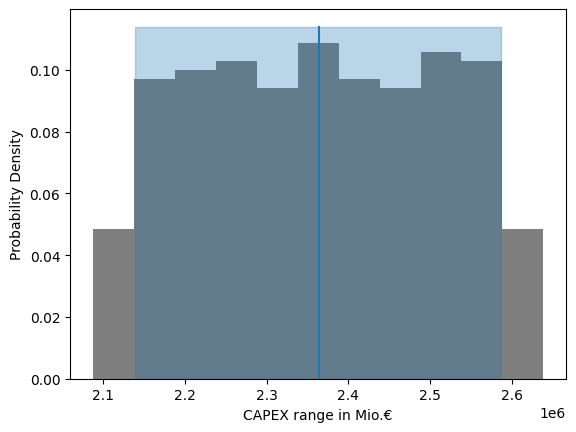

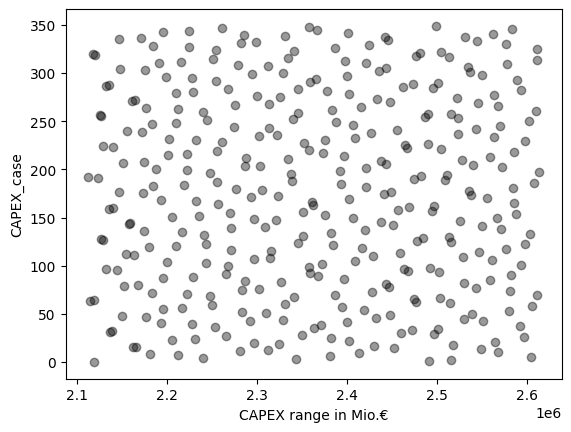

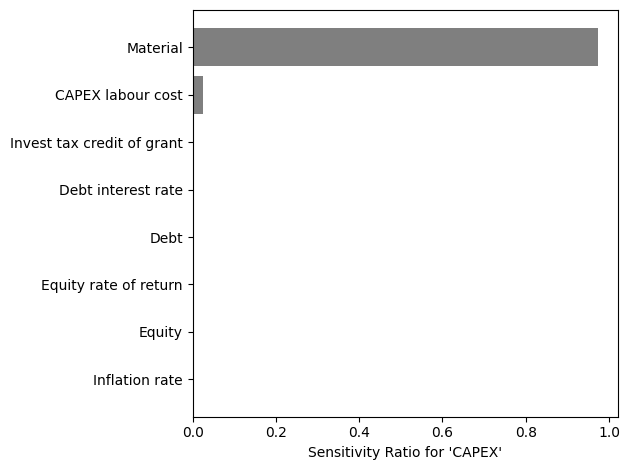

In [5]:
# Monaco CAPEX - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(material, capex_labour, inflation_rate, equity, eq_rate_return, debt, db_intrst_rate, ictg):
    
    # variables used within the monte_capex function (utils.py)
    kwargs={
        'inflation_rate' : inflation_rate,
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        }

    # run the capex simulation
    capex = monte_capex(material=material, capex_labour=capex_labour, ictg=ictg, **kwargs)
    return (capex, )

# Rename the y-aixs in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    material = case.invals['Material'].val
    capex_labour = case.invals['CAPEX labour cost'].val
    inflation_rate = case.invals['Inflation rate'].val
    equity = case.invals['Equity'].val
    eq_rate_return = case.invals['Equity rate of return'].val
    debt = case.invals['Debt'].val
    db_intrst_rate = case.invals['Debt interest rate'].val
    ictg = case.invals['Invest tax credit of grant'].val

    return (material, capex_labour, inflation_rate, equity, eq_rate_return, debt, db_intrst_rate, ictg)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, capex):
    case.addOutVal(name='CAPEX', val=capex)
    case.addOutVal(name='CAPEX_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='CAPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# loc: represents the lower limit of the distribution
# scale: the interval length of the distribution
# e.g: using loc=0 and scale=1 we get a standard uniform distribution on [0, 1]
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Material', dist=uniform, distkwargs={'loc': 1700000, 'scale': 500000})
sim.addInVar(name='CAPEX labour cost', dist=uniform, distkwargs={'loc': 410000, 'scale': 9000})
sim.addInVar(name='Invest tax credit of grant', dist=uniform, distkwargs={'loc': 0.1, 'scale': 1000})
sim.addInVar(name='Inflation rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.001})
sim.addInVar(name='Equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.01})
sim.addInVar(name='Equity rate of return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='Debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='Debt interest rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.001})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['CAPEX'].addVarStat('mean')
sim.outvars['CAPEX'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['CAPEX'])
plt.xlabel('CAPEX range in Mio.€')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['CAPEX'],
sim.outvars['CAPEX_case'])
# add Mio.€ in
plt.xlabel('CAPEX range in Mio.€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('CAPEX')
sim.outvars['CAPEX'].plotSensitivities()

WARNING - (py.warnings._showwarnmsg) - c:\Users\yc20\projects\lcc_tools\.nvenv\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 62204 instead
  warnings.warn(



Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:62204/status
Running 'Material Cost' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 19 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:00.667080
Calculating sensitivity indices for 'Material Cost'...
Calculating optimal hyperparameters Φ for 'Material Cost' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'Material Cost'">)

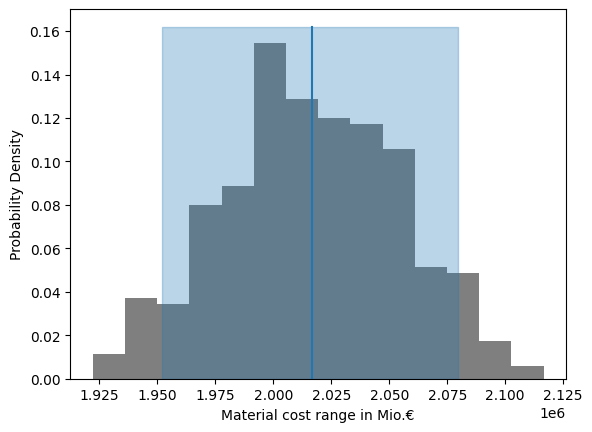

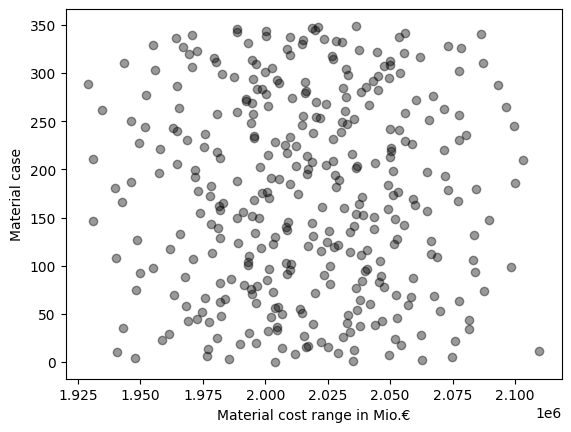

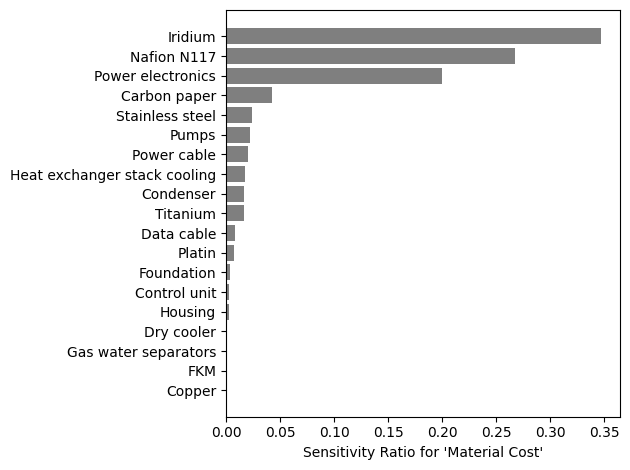

In [6]:
# Monaco material cost - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(steel, copper, titanium, platin, iridium,
                carbon_paper, nafion_N117, 
                FKM, heat_exchanger_stack_cooling, 
                heat_exchanger_condenser, 
                gas_water_separators, dry_cooler, 
                power_cable, data_cable, pumps, inverters, control_unit,
                housing, foundation):

    # run the material cost simulation
    material_cost = monte_pem_capex_5mw_soa(steel=steel, copper=copper, titanium=titanium, platin=platin, iridium=iridium, 
                                               carbon_paper=carbon_paper, nafion_N117=nafion_N117, FKM=FKM, 
                                               heat_exchanger_stack_cooling=heat_exchanger_stack_cooling, 
                                               heat_exchanger_condenser=heat_exchanger_condenser, 
                                               gas_water_separators=gas_water_separators, dry_cooler=dry_cooler, 
                                               power_cable=power_cable, data_cable=data_cable, pumps=pumps, inverters=inverters, control_unit=control_unit,
                                               housing=housing, foundation=foundation)
    return (material_cost, )

# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    steel = case.invals['Stainless steel'].val
    copper = case.invals['Copper'].val
    titanium = case.invals['Titanium'].val
    platin = case.invals['Platin'].val
    iridium = case.invals['Iridium'].val
    carbon_paper = case.invals['Carbon paper'].val
    nafion_N117 = case.invals['Nafion N117'].val
    FKM = case.invals['FKM'].val
    heat_exchanger_stack_cooling = case.invals['Heat exchanger stack cooling'].val
    heat_exchanger_condenser = case.invals['Condenser'].val
    gas_water_separators = case.invals['Gas water separators'].val
    dry_cooler = case.invals['Dry cooler'].val
    power_cable=case.invals['Power cable'].val
    data_cable=case.invals['Data cable'].val
    pumps = case.invals['Pumps'].val
    inverters = case.invals['Power electronics'].val
    control_unit = case.invals['Control unit'].val
    housing = case.invals['Housing'].val
    foundation = case.invals['Foundation'].val

    return (steel, copper, titanium, platin, iridium,
            carbon_paper, nafion_N117, 
            FKM, heat_exchanger_stack_cooling, 
            heat_exchanger_condenser, 
            gas_water_separators, dry_cooler, 
            power_cable, data_cable, pumps, inverters, control_unit,
            housing, foundation)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, construction_cost):
    case.addOutVal(name='Material Cost', val=construction_cost)
    case.addOutVal(name='Material case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350
# Random seed for repeatability
seed = 123456
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='Material Cost', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)


# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Stainless steel', dist=uniform, distkwargs={'loc': 0.5, 'scale': 0.9})
sim.addInVar(name='Copper', dist=uniform, distkwargs={'loc': 6, 'scale': 1})
sim.addInVar(name='Titanium', dist=uniform, distkwargs={'loc': 6, 'scale': 1})
sim.addInVar(name='Platin', dist=uniform, distkwargs={'loc': 27000, 'scale': 3000})
sim.addInVar(name='Iridium', dist=uniform, distkwargs={'loc': 82000, 'scale': 10000})
sim.addInVar(name='Carbon paper', dist=uniform, distkwargs={'loc': 70, 'scale': 30})
sim.addInVar(name='Nafion N117', dist=uniform, distkwargs={'loc': 5800, 'scale': 800})
sim.addInVar(name='FKM', dist=uniform, distkwargs={'loc': 700, 'scale': 100})
sim.addInVar(name='Heat exchanger stack cooling', dist=uniform, distkwargs={'loc': 46000, 'scale': 4000})
sim.addInVar(name='Condenser', dist=uniform, distkwargs={'loc': 46000, 'scale': 4000})
sim.addInVar(name='Gas water separators', dist=uniform, distkwargs={'loc': 2400, 'scale': 100})
sim.addInVar(name='Dry cooler', dist=uniform, distkwargs={'loc': 1400, 'scale': 200})
sim.addInVar(name='Power cable', dist=uniform, distkwargs={'loc': 80, 'scale': 100})
sim.addInVar(name='Data cable', dist=uniform, distkwargs={'loc': 0.5, 'scale': 0.9})
sim.addInVar(name='Pumps', dist=uniform, distkwargs={'loc': 9000, 'scale': 900})
sim.addInVar(name='Power electronics', dist=uniform, distkwargs={'loc': 320000, 'scale': 50000})
sim.addInVar(name='Control unit', dist=uniform, distkwargs={'loc': 6000, 'scale': 800})
sim.addInVar(name='Housing', dist=uniform, distkwargs={'loc': 4800, 'scale': 300})
sim.addInVar(name='Foundation', dist=uniform, distkwargs={'loc': 100, 'scale': 200})


# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['Material Cost'].addVarStat('mean')
sim.outvars['Material Cost'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['Material Cost'])
plt.xlabel('Material cost range in Mio.€')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['Material Cost'],
sim.outvars['Material case'])
plt.xlabel('Material cost range in Mio.€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('Material Cost')
sim.outvars['Material Cost'].plotSensitivities()

In [7]:
# Transport cost

# List all the cost indicators
waste_typs = ['Mixed scrap', 'Waste for recycling', 'Gypsum board, gypsum waste']
price = [0.23, 0.23, 0.1]
unit = ['€/kg']*3

df = pd.DataFrame({
                   'Waste type': waste_typs,
                   'Price': price,
                   'Unit': unit
                  })

df.head()

,Waste type,Price,Unit
0,Mixed scrap,0.230,€/kg
1,Waste for recycling,0.230,€/kg
2,"Gypsum board, gypsum waste",0.100,€/kg


In [8]:
# OPEX S1 and S2 - End of Life (EoL) cost - Salvage value (SV)

# Feed material data and corresponding amount in
material = ['Stainless steel', 'Copper', 'Titanium', 'Platin', 'Iridium', 'Carbon Paper', 'Nafion N117', 'FKM',\
            'Stack Cooling Heat Exchanger', 'Condenser', 'Gas Water Separators', 'Dry Cooler', 'Power Cable',\
            'Data Cable', 'Pumps', 'Inverter', 'Control Unit', 'Housing', 'Foundation']
amount = [625, 68, 3987, 0.75, 9.86, 35, 121, 322.24,\
          1340.45, 1157.73, 1016.62, 4495, 292,\
          103.44, 1800, 6000, 400, 4400, 11250]

# Feed the recycle percentage of the material, corresponding selling price and transport cost in
recycling_rate = [0.88, 0.7, 0.4, 0.76, 0.4, 0, 0, 0,\
                  0.855, 0.855, 0.72, 0.72, 0.72,\
                  0.72, 0.72, 0.72, 0.72, 0.88, 0.89]
disposal_percent = [0.12, 0.3, 0.6, 0.24, 0.6, 1, 1, 1,\
                    0.145, 0.145, 0.28, 0.28, 0.28,\
                    0.28, 0.28, 0.28, 0.28, 0.12, 0.11]
selling_price = [0.23, 7.13, 0, 16780, 0, 0, 0, 0,\
                 0.27, 0.27, 0.27, 0.27, 1.95, \
                 1.95, 0.27, 0.08, 0.08, 0.27, 0]

transport_cost = [0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23,\
                  0.23, 0.23, 0.23, 0.23, 0.23,\
                  0.23, 0.23, 0.23, 0.23, 0.23, 0.1]

# Set the unit
recycle_unit = ['€/kg']*19
material_unit = ['kg']*19
transport_cost_unit = ['€/kg']*19

# Use pandas to orgnize the data and provide the names of the categories in the table
df = pd.DataFrame({'Material' : material, 
                   'Amount':  amount,
                   'Amount unit' : material_unit,
                   'Recycling rate': recycling_rate,
                   'Selling price': selling_price,
                   'Price unit': recycle_unit,                   
                   'Disposal percentage': disposal_percent,
                   'Disposal unit': material_unit,
                   'Transport single cost': transport_cost,
                   'Transport cost unit' : transport_cost_unit
                    })

# Provide the calculation method within the table
df.insert(4, 'Recycling amount', [a*b for a, b in zip(df['Amount'], df['Recycling rate'])])
df.insert(8, 'Disposal amount', [a*b for a, b in zip(df['Amount'], df['Disposal percentage'])])
df.insert(12, 'Transport cost', [a*b for a, b in zip(df['Amount'], df['Transport single cost'])])
df.insert(13, 'Salvage value', [a*b for a, b in zip(df['Recycling amount'], df['Selling price'])])

# Quick hack to change the indices of the df_global dataframe and include the last column to be named "Total"
df = df.append({'Disposal amount': df['Disposal amount'].sum(), 
                'Transport cost': df['Transport cost'].sum(),
                'Salvage value': df['Salvage value'].sum()}, ignore_index=True)

as_list = df.index.tolist()
as_list[-1] = 'Total'
df.index = as_list

df.fillna('', inplace=True)

df.head(20)


WARNING - (py.warnings._showwarnmsg) - C:\Users\yc20\AppData\Local\Temp\ipykernel_11288\2415108693.py:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({'Disposal amount': df['Disposal amount'].sum(),



,Material,Amount,Amount unit,Recycling rate,Recycling amount,Selling price,Price unit,Disposal percentage,Disposal amount,Disposal unit,Transport single cost,Transport cost unit,Transport cost,Salvage value
0,Stainless steel,625.000,kg,0.880,550.000,0.230,€/kg,0.120,75.000,kg,0.230,€/kg,143.750,126.500
1,Copper,68.000,kg,0.700,47.600,7.130,€/kg,0.300,20.400,kg,0.230,€/kg,15.640,339.388
2,Titanium,"3,987.000",kg,0.400,"1,594.800",0.000,€/kg,0.600,"2,392.200",kg,0.230,€/kg,917.010,0.000
3,Platin,0.750,kg,0.760,0.570,"16,780.000",€/kg,0.240,0.180,kg,0.230,€/kg,0.173,"9,564.600"
4,Iridium,9.860,kg,0.400,3.944,0.000,€/kg,0.600,5.916,kg,0.230,€/kg,2.268,0.000
5,Carbon Paper,35.000,kg,0.000,0.000,0.000,€/kg,1.000,35.000,kg,0.230,€/kg,8.050,0.000
6,Nafion N117,121.000,kg,0.000,0.000,0.000,€/kg,1.000,121.000,kg,0.230,€/kg,27.830,0.000
7,FKM,322.240,kg,0.000,0.000,0.000,€/kg,1.000,322.240,kg,0.230,€/kg,74.115,0.000
8,Stack Cooling Heat Exchanger,"1,340.450",kg,0.855,"1,146.085",0.270,€/kg,0.145,194.365,kg,0.230,€/kg,308.304,309.443
9,Condenser,"1,157.730",kg,0.855,989.859,0.270,€/kg,0.145,167.871,kg,0.230,€/kg,266.278,267.262


In [9]:
# OPEX S1 and S2 - Deconstruction cost

# Feed data in function deconstruction_cost (utils.py)
# percentage of cc = percentage of construction cost (for calculate the deconstruction cost)
decon_cost = deconstruction_cost(construction_cost=material_cost, percentage_of_cc=0.06)
print(f"Deconstruction cost {decon_cost:.2f}")

Deconstruction cost 119380.50


In [10]:
 # OPEX S1 and S2 - EoL cost

# EoL cost is caculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25,                        # Equity
        'eq_rate_return': 0.07,                 # Equity rate of return
        'debt': 0.75,                           # Debt
        'db_intrst_rate': 0.045,                # Debt interest rate
        'construction_cost' : material_cost,    # Material cost - comes from table "CAPEX - material cost"
        'percentage_of_cc' : 0.06               # Percentage of material cost (for labour cost)
        }

transport_cost_disposal = df['Transport cost'].loc['Total']
salvage_value = df['Salvage value'].loc['Total']

eol_cost, _ = end_of_life_cost(transport_cost_disposal=transport_cost_disposal, salvage_value=salvage_value, inflation_rate=0.01, **kwargs)
print(f"End of Life {eol_cost:.2f}")

End of Life 50532.02


Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:8787/status
Running 'End Of Life Cost' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 9 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:41.979761
Calculating sensitivity indices for 'EoL Cost'...
Calculating optimal hyperparameters Φ for 'EoL Cost' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'EoL Cost'">)

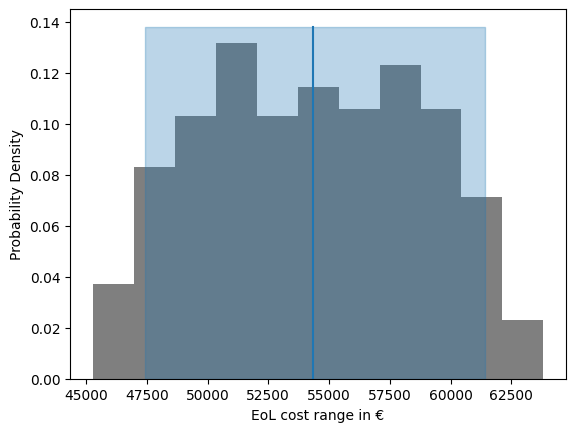

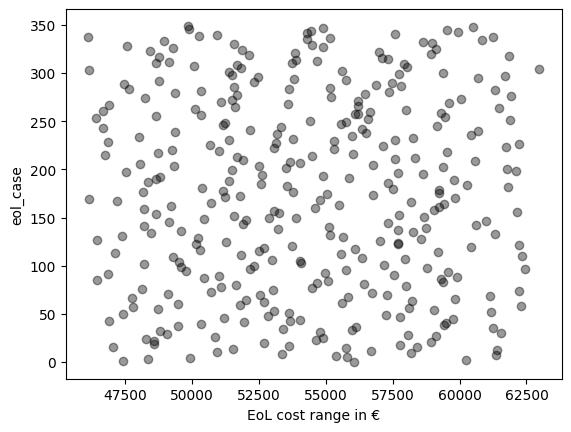

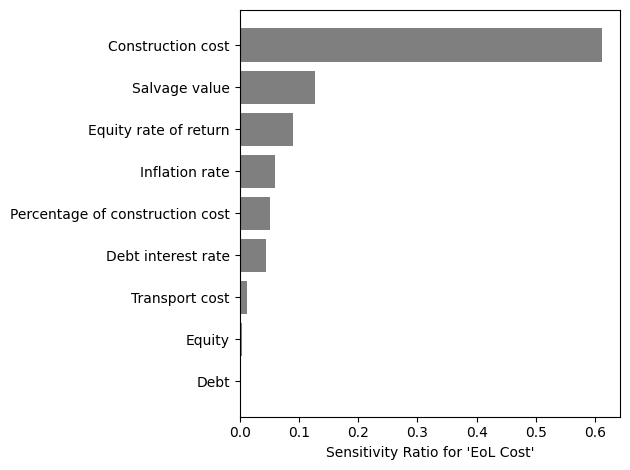

In [11]:
# Monaco EoL cost - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(transport_cost_disposal, salvage_value, construction_cost, percentage_of_cc, inflation_rate, equity, eq_rate_return, \
                debt, db_intrst_rate):
    
    # variables used within the end_of_life_cost function (utils.py)
    kwargs={
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        'construction_cost' : construction_cost,      
        'percentage_of_cc' : percentage_of_cc       
        }
    
    # run the capex simulation
    eol_cost, _ = end_of_life_cost(transport_cost_disposal=transport_cost_disposal, salvage_value=salvage_value, inflation_rate=inflation_rate, \
                                **kwargs)
    return (eol_cost, )

# Rename the y-aixs in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    transport_cost_disposal = case.invals['Transport cost'].val
    salvage_value = case.invals['Salvage value'].val
    construction_cost = case.invals['Construction cost'].val
    percentage_of_cc = case.invals['Percentage of construction cost'].val
    inflation_rate = case.invals['Inflation rate'].val
    equity = case.invals['Equity'].val
    eq_rate_return = case.invals['Equity rate of return'].val
    debt = case.invals['Debt'].val
    db_intrst_rate = case.invals['Debt interest rate'].val

    return (transport_cost_disposal, salvage_value, construction_cost, percentage_of_cc, inflation_rate, equity, eq_rate_return, debt, db_intrst_rate)


# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, eol_cost):
    case.addOutVal(name='EoL Cost', val=eol_cost)
    case.addOutVal(name='eol_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='End Of Life Cost', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Transport cost', dist=uniform, distkwargs={'loc': 7000, 'scale': 500})
sim.addInVar(name='Salvage value', dist=uniform, distkwargs={'loc': 12000, 'scale': 5000})
sim.addInVar(name='Construction cost', dist=uniform, distkwargs={'loc': 1700000, 'scale': 500000})
sim.addInVar(name='Percentage of construction cost', dist=uniform, distkwargs={'loc': 0.06, 'scale': 0.001})
sim.addInVar(name='Inflation rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.001})
sim.addInVar(name='Equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.01})
sim.addInVar(name='Equity rate of return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='Debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='Debt interest rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.001})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['EoL Cost'].addVarStat('mean')
sim.outvars['EoL Cost'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['EoL Cost'])
plt.xlabel('EoL cost range in €')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['EoL Cost'], 
        sim.outvars['eol_case'])
plt.xlabel('EoL cost range in €')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('EoL Cost')
sim.outvars['EoL Cost'].plotSensitivities()


In [3]:
# setup plt plot style
plt.style.use('seaborn-v0_8-ticks')

19:13:11 - cmdstanpy - INFO - Chain [1] start processing
19:13:12 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


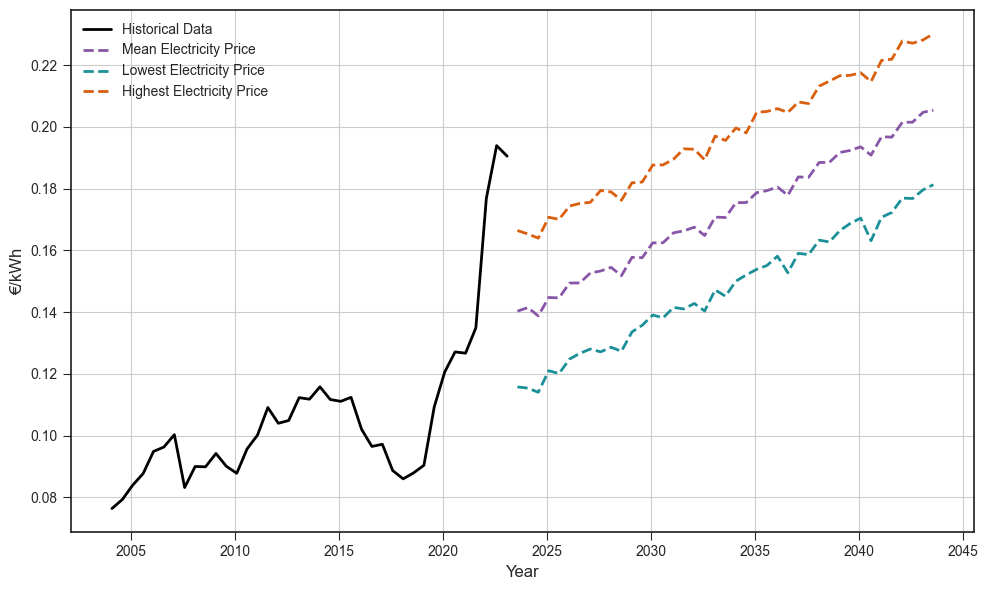

,S1_elc_price_lower,S1_elc_price_upper,S1_elc_price_mean,DATE
0,0.116,0.166,0.140,2023-07-31
1,0.115,0.165,0.141,2024-01-31
2,0.114,0.164,0.139,2024-07-31
3,0.121,0.171,0.145,2025-01-31
4,0.120,0.170,0.145,2025-07-31
5,0.125,0.174,0.149,2026-01-31
6,0.127,0.175,0.149,2026-07-31
7,0.128,0.176,0.153,2027-01-31
8,0.127,0.179,0.153,2027-07-31
9,0.129,0.179,0.154,2028-01-31


In [13]:
# Prophet - electricity (elc.) cost prediction in scenario 1 (S1)

# Insert historical data for elc. cost
df_elc = pd.DataFrame(data=data_elc)

# Run Prophet for elc. cost prediction (here only incl. "Beschaffung, Netzentgelt, Vertrieb"(BNV) + "Konzessionsabgabe"(KA))
# Use Pandas' iloc function to extract the yhat_lower(2), yhat_upper(3) and yhat(15) (mean) from the prophet result dataframe
prophet_NT_hat = prophet_fit_predict_elc(odf=df_elc, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of elc. cost needed to be considered, then... - 
# EEG-Umlage:                     prophet_EEGU_hat = prophet_fit_predict(odf=df_elc, var="EEGU", years=20, plot=False).iloc[: , [2, 3, 15]]
# KWKG-Umlage:                    prophet_KWKG_hat = prophet_fit_predict(odf=df_elc, var="KWKG", years=20, plot=False).iloc[: , [2, 3, 15]]
# §19 StromNEV-Umlage:            prophet_NU_hat = prophet_fit_predict(odf=df_elc, var="19U", years=20, plot=False).iloc[: , [2, 3, 15]]
# Offshore-Netzumlage:            prophet_ONU_hat = prophet_fit_predict(odf=df_elc, var="ONU", years=20, plot=False).iloc[: , [2, 3, 15]]
# Umlage für abschaltbare Lasten: prophet_UAL_hat = prophet_fit_predict(odf=df_elc, var="UAL", years=20, plot=False).iloc[: , [2, 3, 15]]
# Stromsteuer:                    prophet_SST_hat = prophet_fit_predict(odf=df_elc, var="SST", years=20, plot=False).iloc[: , [2, 3, 15]]


# Results of elc. cost prediction (plot + table)
# Apply an add reduce lambda function to the values of each row in prophet_BNV_hat and prophet_KA_hat
prophet_preds_elc = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
prophet_preds_elc['DATE'] = pd.date_range(start="2023-07-31", end="2043-07-31", freq="6M")
prophet_preds_elc.rename(columns = {'yhat':'S1_elc_price_mean', 'yhat_lower':'S1_elc_price_lower',
                                    'yhat_upper':'S1_elc_price_upper'}, inplace = True)

# Sum all ground-truth data and predictions
df_elc['History'] = df_elc.sum(axis=1, numeric_only=True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc['DATE'], df_elc['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc.head(50)

19:13:12 - cmdstanpy - INFO - Chain [1] start processing
19:13:13 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 3 Years...


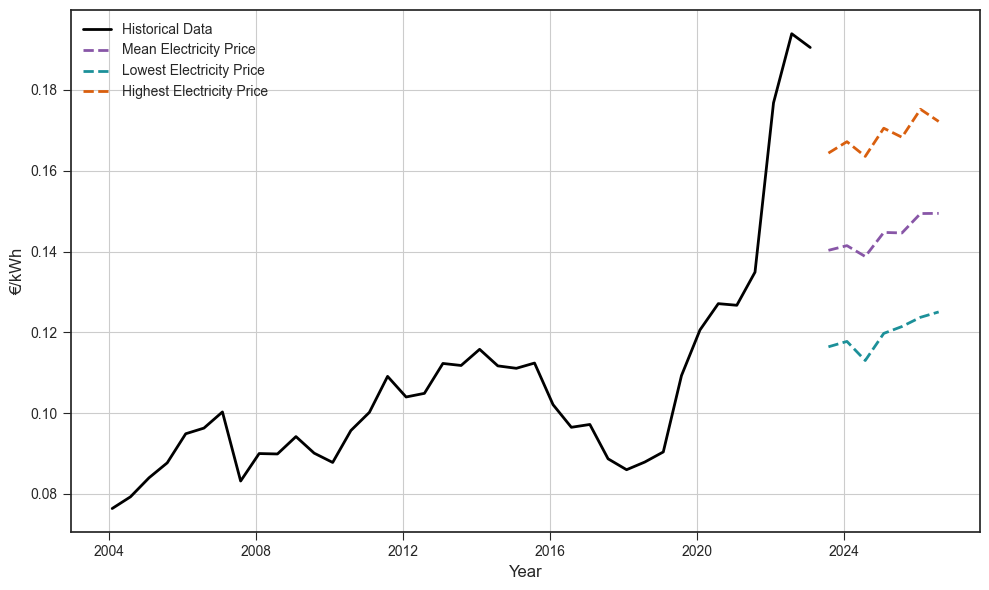

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.116,0.164,0.140,2023-07-31
1,0.118,0.167,0.141,2024-01-31
2,0.113,0.164,0.139,2024-07-31
3,0.120,0.171,0.145,2025-01-31
4,0.121,0.168,0.145,2025-07-31
5,0.124,0.175,0.149,2026-01-31
6,0.125,0.172,0.149,2026-07-31


In [14]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.1

# For elctricity and water price prediction
df_elc_3y = pd.DataFrame(data=data_elc)

# Electricity cost prediction - 3 years with consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_3_years_after_war(odf=df_elc_3y, var="no_tax", years=3, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - 3 years with consideration of war and epidemic
prophet_preds_elc_3y = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_3y['History'] = df_elc_3y.sum(axis=1, numeric_only=True)
prophet_preds_elc_3y['DATE'] = pd.date_range(start="2023-07-31", end="2026-07-31", freq="6M")
prophet_preds_elc_3y.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_3y['DATE'], df_elc_3y['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))


# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc_3y.head(50)

19:13:13 - cmdstanpy - INFO - Chain [1] start processing
19:13:13 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


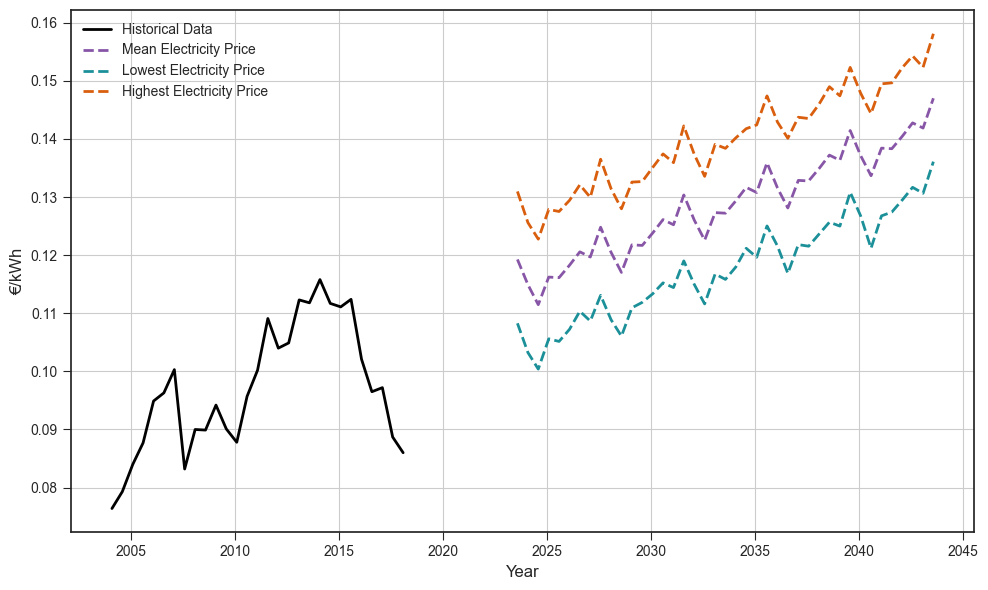

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.108,0.131,0.119,2023-07-31
1,0.103,0.126,0.115,2024-01-31
2,0.100,0.123,0.111,2024-07-31
3,0.106,0.128,0.116,2025-01-31
4,0.105,0.128,0.116,2025-07-31
5,0.107,0.129,0.118,2026-01-31
6,0.110,0.132,0.121,2026-07-31
7,0.109,0.130,0.120,2027-01-31
8,0.113,0.137,0.125,2027-07-31
9,0.109,0.131,0.120,2028-01-31


In [15]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2

df_elc_rest = pd.DataFrame(data=data_nw_elc)

# Electricity cost prediction - without consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_elc_rest(odf=df_elc_rest, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - after 3 years, the impact of war and epedemic will be gone, everything will be back to "normal" (cost trend before 2019)
prophet_preds_elc_nw = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_rest['History'] = df_elc_rest.sum(axis=1, numeric_only=True)
prophet_preds_elc_nw['DATE'] = pd.date_range(start="2023-07-31", end="2043-07-31", freq="6M")
prophet_preds_elc_nw.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_rest['DATE'], df_elc_rest['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


#ax = df_elc_rest.plot(kind='line', x='DATE', y='History')
#prophet_preds_elc_nw.plot(ax = ax, x='DATE')

#plt.show()

prophet_preds_elc_nw.head(50)


In [16]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.1
# List of electricity price prediction - without 2023-2026

prophet_elc_rest=prophet_preds_elc_nw.head(50)
prophet_elc_rest.drop([0, 1, 2, 3, 4, 5, 6], axis=0, inplace=True)
print(prophet_elc_rest)

WARNING - (py.warnings._showwarnmsg) - C:\Users\yc20\AppData\Local\Temp\ipykernel_11288\3551744400.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_elc_rest.drop([0, 1, 2, 3, 4, 5, 6], axis=0, inplace=True)



     S2_elc_price_lower   S2_elc_price_upper    S2_elc_price_mean       DATE
7                 0.109                0.130                0.120 2027-01-31
8                 0.113                0.137                0.125 2027-07-31
9                 0.109                0.131                0.120 2028-01-31
10                0.106                0.128                0.117 2028-07-31
11                0.111                0.133                0.122 2029-01-31
12                0.112                0.133                0.122 2029-07-31
13                0.113                0.135                0.124 2030-01-31
14                0.115                0.137                0.126 2030-07-31
15                0.114                0.136                0.125 2031-01-31
16                0.119                0.142                0.130 2031-07-31
17                0.115                0.137                0.126 2032-01-31
18                0.112                0.134                0.123 2032-07-31

In [17]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.2
# Combine the 2 prediction together - list it

prophet_elc_price = pd.concat([prophet_preds_elc_3y, prophet_elc_rest], axis=0)
prophet_elc_price.head(50)

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.116,0.164,0.140,2023-07-31
1,0.118,0.167,0.141,2024-01-31
2,0.113,0.164,0.139,2024-07-31
3,0.120,0.171,0.145,2025-01-31
4,0.121,0.168,0.145,2025-07-31
5,0.124,0.175,0.149,2026-01-31
6,0.125,0.172,0.149,2026-07-31
7,0.109,0.130,0.120,2027-01-31
8,0.113,0.137,0.125,2027-07-31
9,0.109,0.131,0.120,2028-01-31


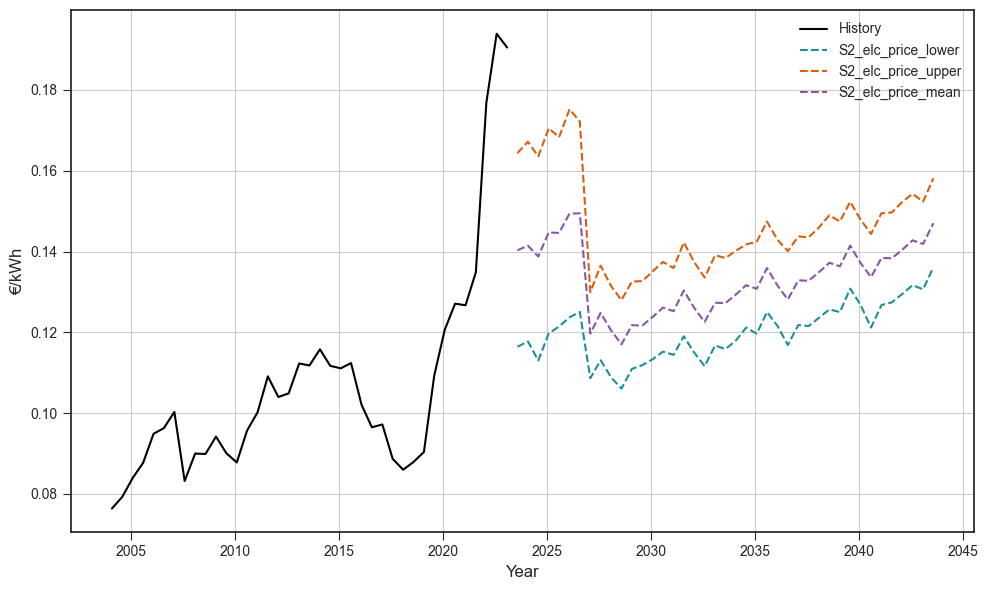

In [18]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 2
# Combine the 2 prediction together, plot the final S2 prediction

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred, lower_data, color=(28/255, 144/255, 153/255), linestyle='--', label='S2_elc_price_lower')
ax.plot(date_pred, upper_data, color=(217/255, 95/255, 14/255), linestyle='--', label='S2_elc_price_upper')
ax.plot(date_pred, pred_data, color=(136/255, 86/255, 167/255), linestyle='--', label='S2_elc_price_mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
# If:
#   title is needed
# Then:
#   ax.set_title('S2', fontsize=14)
ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


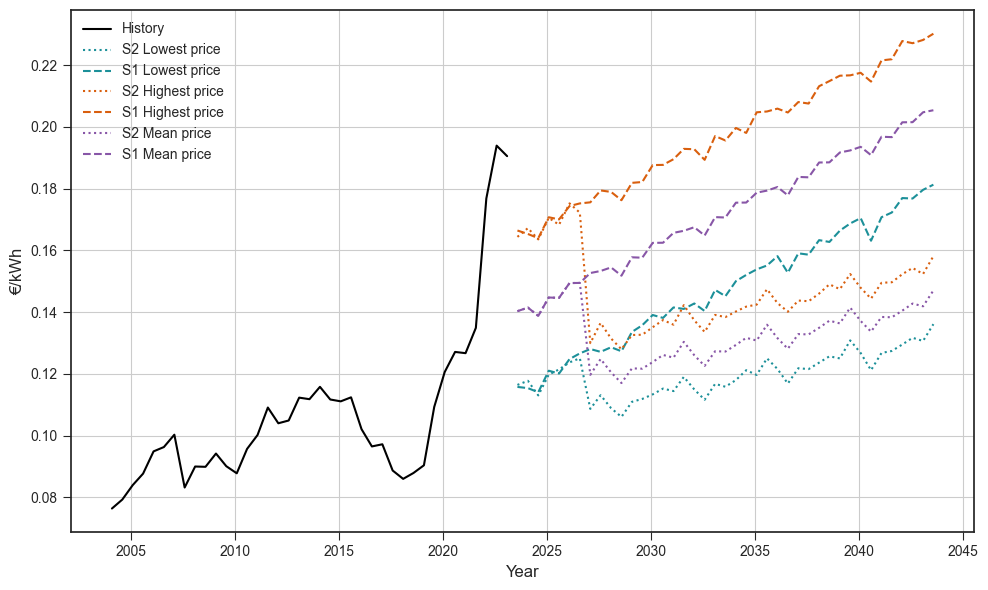

In [19]:
# Prophet - Combine the results of elc. cost in S1 and S2 together - For manuscript

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred, lower_data, color=(28/255, 144/255, 153/255), linestyle='dotted', label='S2 Lowest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_lower'].to_list(), color=(28/255, 144/255, 153/255), linestyle='--', label='S1 Lowest price')
ax.plot(date_pred, upper_data, color=(217/255, 95/255, 14/255), linestyle='dotted', label='S2 Highest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_upper'].to_list(), color=(217/255, 95/255, 14/255), linestyle='--', label='S1 Highest price')
ax.plot(date_pred, pred_data, color=(136/255, 86/255, 167/255), linestyle='dotted', label='S2 Mean price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_mean'].to_list(), color=(136/255, 86/255, 167/255), linestyle='--', label='S1 Mean price')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)

ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


19:13:15 - cmdstanpy - INFO - Chain [1] start processing
19:13:15 - cmdstanpy - INFO - Chain [1] done processing


Predicting WF for 20 Years...


19:13:15 - cmdstanpy - INFO - Chain [1] start processing
19:13:16 - cmdstanpy - INFO - Chain [1] done processing


Predicting WWF for 20 Years...


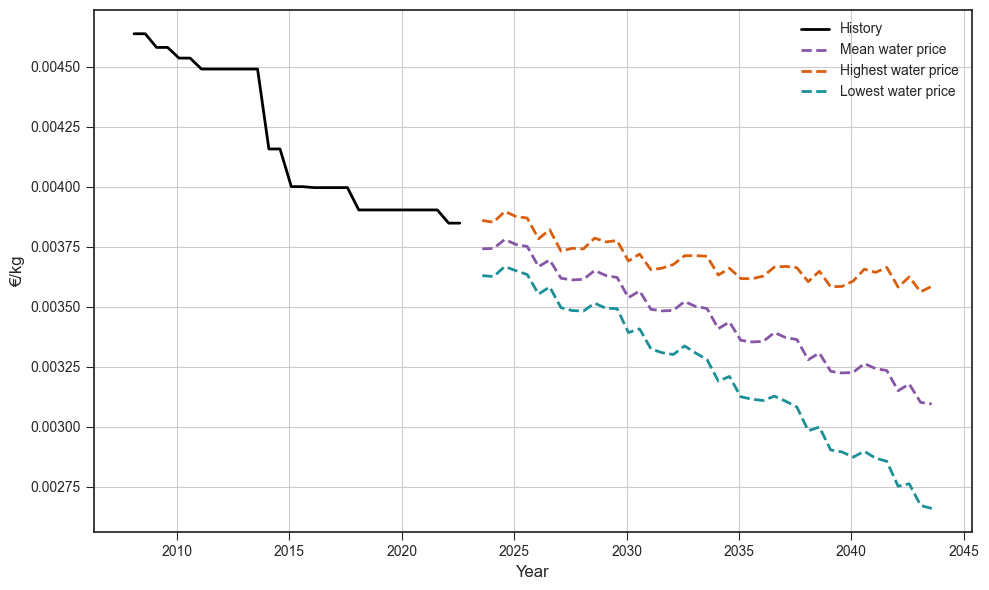

,wat_price_lower,wat_price_upper,wat_price_mean,DATE
0,0.004,0.004,0.004,2023-07-31
1,0.004,0.004,0.004,2024-01-31
2,0.004,0.004,0.004,2024-07-31
3,0.004,0.004,0.004,2025-01-31
4,0.004,0.004,0.004,2025-07-31
5,0.004,0.004,0.004,2026-01-31
6,0.004,0.004,0.004,2026-07-31
7,0.003,0.004,0.004,2027-01-31
8,0.003,0.004,0.004,2027-07-31
9,0.003,0.004,0.004,2028-01-31


In [20]:
# Prophet - water cost prediction

# Insert historical data for water
df = pd.DataFrame(water_data)

# Run package Prophet for water cost prediction (here only incl. "Water fee"(WF) and "Waste water fee"(WWF))
prophet_WF_hat = prophet_fit_predict_water(odf=df, var="WF", years=20, plot=False).iloc[: , [2, 3, 15]]
prophet_WWF_hat = prophet_fit_predict_water(odf=df, var="WWF", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of water needed to be considered... - 
# Value added tax: prophet_VAT_hat = prophet_fit_predict_material(odf=df, var="VAT", years=20, plot=False).iloc[: , [2, 3, 15]]

# Results of water cost prediction (plot + table)
prophet_preds_wat = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_WF_hat,
                                                                 prophet_WWF_hat 
                                                                 ])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df['History'] = df.sum(axis=1, numeric_only=True)

# Sum all ground-truth data and predictions
prophet_preds_wat['DATE'] = pd.date_range(start="2023-07-31", end="2043-07-31", freq="6M")
prophet_preds_wat.rename(columns = {'yhat':'wat_price_mean', 'yhat_lower':'wat_price_lower',
                                    'yhat_upper':'wat_price_upper'}, inplace = True)

# Create subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot ground truth data
ax.plot(df['DATE'], df['History'], label='History', linestyle='-', linewidth=2, color='black')

# Plot predictions
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_mean'], label='Mean water price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_upper'], label='Highest water price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_lower'], label='Lowest water price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))

# Add labels for x and y-axis
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kg', fontsize=12)

# Set x-axis ticks every 5 years starting from 2005
ax.xaxis.set_major_locator(mdates.YearLocator(base=5, month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#ax.set_title('Water Cost Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_wat.head(50)

In [21]:
# OPEX S1 - resource cost (water and electricity) for 5 MW PEM

h2_produced_amount = [444911.5105]*41      # total 444911.5105 kg of H2 will be produced within half year; column start from 0, so we need 41 column to represent 20 years
h2_unit_elc = ['kg']*41                    # feed unit for the list 
elc_used_amount = [56.33]*41               # need 56.33 kWh of elc. to produce 1 kg H2
wat_used_amount = [9.3]*41                 # need app. 9.30 kg of water to produce 1 kg H2
elc_price_unit = ['€/kWh']*41              # feed unit for the list 
wat_price_unit = ['€/kg']*41               # as above 


# Provide the names of the categories in the table
df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit':  h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit':wat_price_unit,                   
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                    })

# Add predicted data from Prophet (elc. and water) in the table
cols_order = prophet_preds_wat.columns.to_list()

# Drop 'DATE' column from the prophet_preds_wat dataframe as no prediction as going to be run
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)

# Concatenate horizontally the prophet electrecity and water dataframes
df_global = pd.concat([df, n_prophet_preds_wat, prophet_preds_elc], axis=1)

print(df_global.columns.tolist())

# Provide the calculation method within the table
df_global.insert(7, 'S1 Water Price_Lower', [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])])
df_global.insert(9, 'S1 Water Price_Higher', [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])])
df_global.insert(11, 'S1 Water Price_Mean', [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])])
df_global.insert(13, 'S1 Electricity Price_Lower', [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S1_elc_price_lower'])])
df_global.insert(15, 'S1 Electricity Price_Higher', [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S1_elc_price_upper'])])
df_global.insert(17, 'S1 Electricity Price_Mean', [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S1_elc_price_mean'])])
df_global.insert(18, 'S1 Total Resources Price Lower', [a+b for a, b in zip(df_global['S1 Electricity Price_Lower'], df_global['S1 Water Price_Lower'])])
df_global.insert(19, 'S1 Total Resources Price Higher', [a+b for a, b in zip(df_global['S1 Electricity Price_Higher'], df_global['S1 Water Price_Higher'])])
df_global.insert(20, 'S1 Total Resources Price Mean', [a+b for a, b in zip(df_global['S1 Electricity Price_Mean'], df_global['S1 Water Price_Mean'])])


# Quick hack to change the indices of the df_global dataframe and include the last column to be named "Total"
df_global = df_global.append({'S1 Electricity Price_Mean': df_global['S1 Electricity Price_Mean'].sum(),
                              'S1 Electricity Price_Higher': df_global['S1 Electricity Price_Higher'].sum(), 
                              'S1 Electricity Price_Lower': df_global['S1 Electricity Price_Lower'].sum(),   
                              'S1 Water Price_Mean': df_global['S1 Water Price_Mean'].sum(), 
                              'S1 Water Price_Higher': df_global['S1 Water Price_Higher'].sum(),
                              'S1 Water Price_Lower': df_global['S1 Water Price_Lower'].sum(),  
                              'S1 Total Resources Price Mean': df_global['S1 Total Resources Price Mean'].sum(),
                              'S1 Total Resources Price Higher': df_global['S1 Total Resources Price Higher'].sum(),
                              'S1 Total Resources Price Lower': df_global['S1 Total Resources Price Lower'].sum()}, ignore_index=True)
as_list = df_global.index.tolist()
as_list[-1] = 'Total'
df_global.index = as_list

df_global.fillna('', inplace=True)


# Add 'DATE' column to the df_global dataframe
cols_order = df_global.columns.tolist()

del cols_order[cols_order.index('DATE')]

cols_order.insert(0, 'DATE')

df_global = df_global[cols_order]

df_global.head(50)

WARNING - (py.warnings._showwarnmsg) - C:\Users\yc20\AppData\Local\Temp\ipykernel_11288\3289584144.py:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_global = df_global.append({'S1 Electricity Price_Mean': df_global['S1 Electricity Price_Mean'].sum(),



['H2 Production', 'H2 Unit', 'Needed Water', 'Water Price Unit', 'Needed Electricity', 'Electricity Price Unit', 'wat_price_lower', 'wat_price_upper', 'wat_price_mean', 'S1_elc_price_lower', 'S1_elc_price_upper', 'S1_elc_price_mean', 'DATE']


,DATE,H2 Production,H2 Unit,Needed Water,Water Price Unit,Needed Electricity,Electricity Price Unit,wat_price_lower,S1 Water Price_Lower,wat_price_upper,...,S1 Water Price_Mean,S1_elc_price_lower,S1 Electricity Price_Lower,S1_elc_price_upper,S1 Electricity Price_Higher,S1_elc_price_mean,S1 Electricity Price_Mean,S1 Total Resources Price Lower,S1 Total Resources Price Higher,S1 Total Resources Price Mean
0,2023-07-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"15,020.483",0.004,...,"15,482.278",0.116,"2,901,406.733",0.166,"4,170,630.629",0.140,"3,516,062.989","2,916,427.216","4,186,602.102","3,531,545.266"
1,2024-01-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"15,005.620",0.004,...,"15,490.831",0.115,"2,891,751.623",0.165,"4,142,599.868",0.141,"3,545,218.432","2,906,757.243","4,158,541.364","3,560,709.264"
2,2024-07-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"15,177.422",0.004,...,"15,643.901",0.114,"2,857,999.501",0.164,"4,108,691.462",0.139,"3,477,839.406","2,873,176.923","4,124,818.961","3,493,483.307"
3,2025-01-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"15,105.223",0.004,...,"15,557.013",0.121,"3,032,883.705",0.171,"4,278,268.841",0.145,"3,627,098.743","3,047,988.928","4,294,308.609","3,642,655.756"
4,2025-07-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"15,039.939",0.004,...,"15,523.785",0.120,"3,010,041.939",0.170,"4,260,947.648",0.145,"3,623,937.722","3,025,081.878","4,276,961.063","3,639,461.507"
5,2026-01-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"14,701.868",0.004,...,"15,175.828",0.125,"3,127,329.724",0.174,"4,369,085.430",0.149,"3,744,240.650","3,142,031.593","4,384,741.694","3,759,416.478"
6,2026-07-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.004,"14,826.987",0.004,...,"15,291.687",0.127,"3,173,534.891",0.175,"4,390,583.981",0.149,"3,745,389.072","3,188,361.878","4,406,396.029","3,760,680.759"
7,2027-01-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.003,"14,468.343",0.004,...,"14,975.501",0.128,"3,208,889.719",0.176,"4,399,402.328",0.153,"3,825,669.950","3,223,358.062","4,414,845.336","3,840,645.451"
8,2027-07-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.003,"14,418.775",0.004,...,"14,947.550",0.127,"3,186,037.759",0.179,"4,495,912.658",0.153,"3,842,192.830","3,200,456.534","4,511,404.219","3,857,140.380"
9,2028-01-31,"444,911.510",kg,9.300,€/kg,56.330,€/kWh,0.003,"14,410.212",0.004,...,"14,956.104",0.129,"3,223,389.913",0.179,"4,483,801.255",0.154,"3,871,348.274","3,237,800.125","4,499,283.840","3,886,304.378"


In [22]:
# OPEX S1 (with EoL cost) - Details
# S1_mean

# OPEX S1 (Mean) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_mean = df_global['S1 Total Resources Price Mean'].tolist()

op_cost_S1_mean = operation_cost(resource_cost=S1_resource_cost_mean, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_mean:.2f}")

Labour Cost: 49741.874162500004
End of life Cost: 50532.02471644743
Operation Cost: 69836881.96


In [23]:
# OPEX S1 (with EoL cost) - Details
# S1_higher

# OPEX S1 (High) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_high = df_global['S1 Total Resources Price Higher'].tolist()

op_cost_S1_high = operation_cost(resource_cost=S1_resource_cost_high, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_high:.2f}")

Labour Cost: 49741.874162500004
End of life Cost: 50532.02471644743
Operation Cost: 80019830.57


In [24]:
# OPEX S1 (with EoL cost) - Details
# S1_lower

# OPEX S1 (Low) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_low = df_global['S1 Total Resources Price Lower'].tolist()

op_cost_S1_low = operation_cost(resource_cost=S1_resource_cost_low, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_low:.2f}")

Labour Cost: 49741.874162500004
End of life Cost: 50532.02471644743
Operation Cost: 59790154.30


WARNING - (py.warnings._showwarnmsg) - c:\Users\yc20\projects\lcc_tools\.nvenv\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 62379 instead
  warnings.warn(



Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:62379/status
Running 'OPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:00.248432
Calculating sensitivity indices for 'OPEX_S1'...
Calculating optimal hyperparameters Φ for 'OPEX_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'OPEX_S1'">)

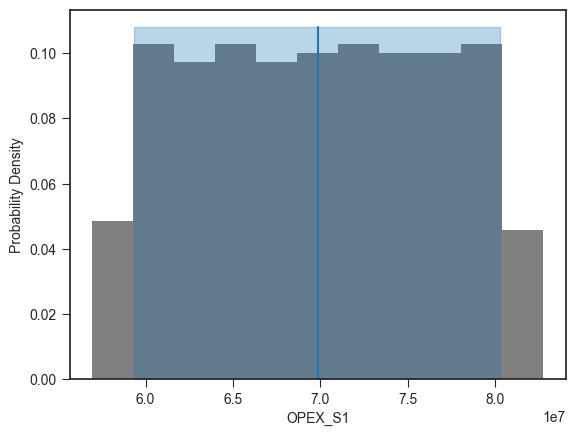

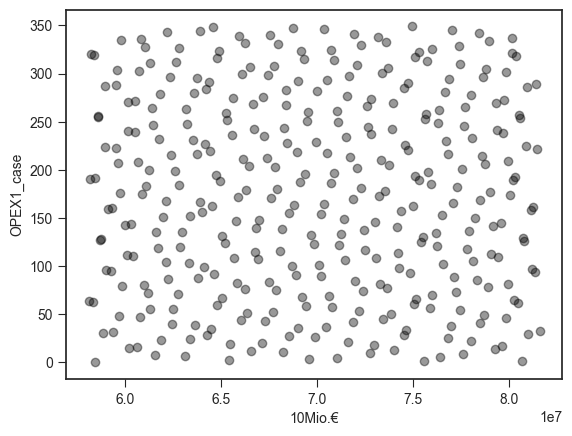

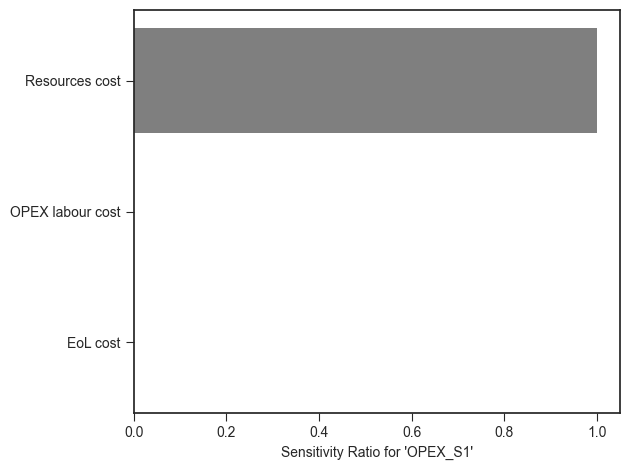

In [25]:
# Monaco OPEX S1 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(op_cost, op_labour, eol_cost):

    # run the opex simulation
    opr_cost = monte_opex(op_cost=op_cost, op_labour=op_labour, eol_cost=eol_cost)
    return (opr_cost, )

# Rename the y-aixs in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    op_cost = case.invals['Resources cost'].val
    op_labour = case.invals['OPEX labour cost'].val
    eol_cost = case.invals['EoL cost'].val

    return (op_cost, op_labour, eol_cost)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, opr_cost):
    case.addOutVal(name='OPEX_S1', val=opr_cost)
    case.addOutVal(name='OPEX1_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='OPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# loc: represents the lower limit of the distribution
# scale: the interval length of the distribution
# e.g: using loc=0 and scale=1 we get a standard uniform distribution on [0, 1]
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Resources cost', dist=uniform, distkwargs={'loc': 58000000, 'scale': 23500000})
sim.addInVar(name='OPEX labour cost', dist=uniform, distkwargs={'loc': 45000, 'scale': 10000})
sim.addInVar(name='EoL cost', dist=uniform, distkwargs={'loc': 50000, 'scale': 2000})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# statistics for the dice sum
sim.outvars['OPEX_S1'].addVarStat('mean')
sim.outvars['OPEX_S1'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['OPEX_S1'])
# Creates a scatter plot of the sum vs the roll
# number, showing randomness
mc.plot(sim.outvars['OPEX_S1'],
sim.outvars['OPEX1_case'])

# add Mio.€ in
plt.xlabel('10Mio.€')

# Calculate the sensitivity of the dice sum to
# each of the input variables
sim.calcSensitivities('OPEX_S1')
sim.outvars['OPEX_S1'].plotSensitivities()

In [26]:
# OPEX S2 - resource cost (water and electricity) for 5 MW PEM

h2_produced_amount = [444911.5105]*41  # total 444911.5105 kg of H2 will be produced within half year; 
                                       # column start from 0, so we need 41 column to represent 20 years
h2_unit_elc = ['kg']*41                    # feed unit for the list 
elc_used_amount = [56.34]*41               # need 56.34 kWh of elc. to produce 1 kg H2
wat_used_amount = [9.3]*41           # need app. 9.28 kg of water to produce 1 kg H2
elc_price_unit = ['€/kWh']*41              # feed unit for the list 
wat_price_unit = ['€/kg']*41               # as above 


# Provide the names of the categories in the table
df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit':  h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit':wat_price_unit,                   
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                    })

# Add predicted data from Prophet (elc. and water) in the table
cols_order = prophet_preds_wat.columns.to_list()

# Drop 'DATE' column from the prophet_preds_wat dataframe as no prediction is going to be run
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)

# Concatenate horizontally the prophet electrecity and water dataframes
df_global = pd.concat([df, n_prophet_preds_wat, prophet_elc_price], axis=1)

print(df_global.columns.tolist())

# Provide the calculation method within the table
df_global.insert(7, 'S2 Water Price_Lower', 
                 [a*b*c for a, b, c in zip(df_global['H2 Production'], 
                                           df_global['Needed Water'], df_global['wat_price_lower'])])

df_global.insert(9, 'S2 Water Price_Higher', 
                 [a*b*c for a, b, c in zip(df_global['H2 Production'], 
                                           df_global['Needed Water'], df_global['wat_price_upper'])])

df_global.insert(11, 'S2 Water Price_Mean', 
                 [a*b*c for a, b, c in zip(df_global['H2 Production'], 
                                           df_global['Needed Water'], df_global['wat_price_mean'])])

df_global.insert(13, 'S2 Electricity Price_Lower', 
                 [a*b*c for a, b, c in zip(df_global['H2 Production'], 
                                           df_global['Needed Electricity'], df_global['S2_elc_price_lower'])])

df_global.insert(15, 'S2 Electricity Price_Higher', 
                 [a*b*c for a, b, c in zip(df_global['H2 Production'], 
                                           df_global['Needed Electricity'], df_global['S2_elc_price_upper'])])

df_global.insert(17, 'S2 Electricity Price_Mean', 
                 [a*b*c for a, b, c in zip(df_global['H2 Production'], 
                                           df_global['Needed Electricity'], df_global['S2_elc_price_mean'])])

df_global.insert(18, 'S2 Total Resources Price Lower', 
                 [a+b for a, b in zip(df_global['S2 Electricity Price_Lower'], 
                                      df_global['S2 Water Price_Lower'])])

df_global.insert(19, 'S2 Total Resources Price Higher', 
                 [a+b for a, b in zip(df_global['S2 Electricity Price_Higher'], 
                                      df_global['S2 Water Price_Higher'])])

df_global.insert(20, 'S2 Total Resources Price Mean', 
                 [a+b for a, b in zip(df_global['S2 Electricity Price_Mean'], 
                                      df_global['S2 Water Price_Mean'])])


# Quick hack to change the indices of the df_global dataframe and include the last column to be named "Total"
df_global = df_global.append({'S2 Electricity Price_Mean': df_global['S2 Electricity Price_Mean'].sum(),
                              'S2 Electricity Price_Higher': df_global['S2 Electricity Price_Higher'].sum(), 
                              'S2 Electricity Price_Lower': df_global['S2 Electricity Price_Lower'].sum(),   
                              'S2 Water Price_Mean': df_global['S2 Water Price_Mean'].sum(), 
                              'S2 Water Price_Higher': df_global['S2 Water Price_Higher'].sum(),
                              'S2 Water Price_Lower': df_global['S2 Water Price_Lower'].sum(),  
                              'S2 Total Resources Price Mean': df_global['S2 Total Resources Price Mean'].sum(),
                              'S2 Total Resources Price Higher': df_global['S2 Total Resources Price Higher'].sum(),
                              'S2 Total Resources Price Lower': df_global['S2 Total Resources Price Lower'].sum()}, ignore_index=True)
as_list = df_global.index.tolist()
as_list[-1] = 'Total'
df_global.index = as_list

df_global.fillna('', inplace=True)


# Add 'DATE' column to the df_global dataframe
cols_order = df_global.columns.tolist()

del cols_order[cols_order.index('DATE')]

cols_order.insert(0, 'DATE')

df_global = df_global[cols_order]

df_global.head(50)

WARNING - (py.warnings._showwarnmsg) - C:\Users\yc20\AppData\Local\Temp\ipykernel_11288\1114077004.py:71: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_global = df_global.append({'S2 Electricity Price_Mean': df_global['S2 Electricity Price_Mean'].sum(),



['H2 Production', 'H2 Unit', 'Needed Water', 'Water Price Unit', 'Needed Electricity', 'Electricity Price Unit', 'wat_price_lower', 'wat_price_upper', 'wat_price_mean', 'S2_elc_price_lower', 'S2_elc_price_upper', 'S2_elc_price_mean', 'DATE']


,DATE,H2 Production,H2 Unit,Needed Water,Water Price Unit,Needed Electricity,Electricity Price Unit,wat_price_lower,S2 Water Price_Lower,wat_price_upper,...,S2 Water Price_Mean,S2_elc_price_lower,S2 Electricity Price_Lower,S2_elc_price_upper,S2 Electricity Price_Higher,S2_elc_price_mean,S2 Electricity Price_Mean,S2 Total Resources Price Lower,S2 Total Resources Price Higher,S2 Total Resources Price Mean
0,2023-07-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"15,020.483",0.004,...,"15,482.278",0.116,"2,918,238.332",0.164,"4,119,890.989",0.140,"3,516,687.179","2,933,258.815","4,135,862.462","3,532,169.456"
1,2024-01-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"15,005.620",0.004,...,"15,490.831",0.118,"2,951,535.375",0.167,"4,190,699.130",0.141,"3,545,847.798","2,966,540.996","4,206,640.627","3,561,338.629"
2,2024-07-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"15,177.422",0.004,...,"15,643.901",0.113,"2,833,207.747",0.164,"4,099,617.766",0.139,"3,478,456.810","2,848,385.169","4,115,745.265","3,494,100.711"
3,2025-01-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"15,105.223",0.004,...,"15,557.013",0.120,"3,001,476.077",0.171,"4,274,228.878",0.145,"3,627,742.645","3,016,581.300","4,290,268.646","3,643,299.658"
4,2025-07-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"15,039.939",0.004,...,"15,523.785",0.121,"3,044,066.306",0.168,"4,218,115.836",0.145,"3,624,581.062","3,059,106.246","4,234,129.251","3,640,104.847"
5,2026-01-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"14,701.868",0.004,...,"15,175.828",0.124,"3,101,152.582",0.175,"4,391,854.930",0.149,"3,744,905.347","3,115,854.450","4,407,511.194","3,760,081.175"
6,2026-07-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.004,"14,826.987",0.004,...,"15,291.687",0.125,"3,134,477.381",0.172,"4,316,186.087",0.149,"3,746,053.974","3,149,304.368","4,331,998.135","3,761,345.660"
7,2027-01-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.003,"14,468.343",0.004,...,"14,975.501",0.109,"2,723,684.176",0.130,"3,257,251.531",0.120,"3,000,138.309","2,738,152.519","3,272,694.539","3,015,113.810"
8,2027-07-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.003,"14,418.775",0.004,...,"14,947.550",0.113,"2,834,715.535",0.137,"3,421,773.151",0.125,"3,128,617.741","2,849,134.310","3,437,264.712","3,143,565.292"
9,2028-01-31,"444,911.510",kg,9.300,€/kg,56.340,€/kWh,0.003,"14,410.212",0.004,...,"14,956.104",0.109,"2,729,290.586",0.131,"3,294,534.663",0.120,"3,019,969.184","2,743,700.797","3,310,017.247","3,034,925.288"


In [27]:
# OPEX S2 (with EoL cost) - Details
# S2_mean

# OPEX S2 (Mean) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_mean = df_global['S2 Total Resources Price Mean'].tolist()

op_cost_S2_mean = operation_cost(resource_cost=S2_resource_cost_mean, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_mean:.2f}")

Labour Cost: 49741.874162500004
End of life Cost: 50532.02471644743
Operation Cost: 54584873.86


In [28]:
# OPEX S2 (with EoL cost) - Details
# S2_higher

# OPEX S2 (High) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_high = df_global['S2 Total Resources Price Higher'].tolist()

op_cost_S2_high = operation_cost(resource_cost=S2_resource_cost_high, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_high:.2f}")

Labour Cost: 49741.874162500004
End of life Cost: 50532.02471644743
Operation Cost: 60150504.11


In [29]:
# OPEX S2 (with EoL cost) - Details
# S2_lower

# OPEX S2 (Low) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_low = df_global['S2 Total Resources Price Lower'].tolist()

op_cost_S2_low = operation_cost(resource_cost=S2_resource_cost_low, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_low:.2f}")

Labour Cost: 49741.874162500004
End of life Cost: 50532.02471644743
Operation Cost: 49066094.02


Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:8787/status
Running 'OPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:25.450735
Calculating sensitivity indices for 'OPEX_S2'...
Calculating optimal hyperparameters Φ for 'OPEX_S2' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'OPEX_S2'">)

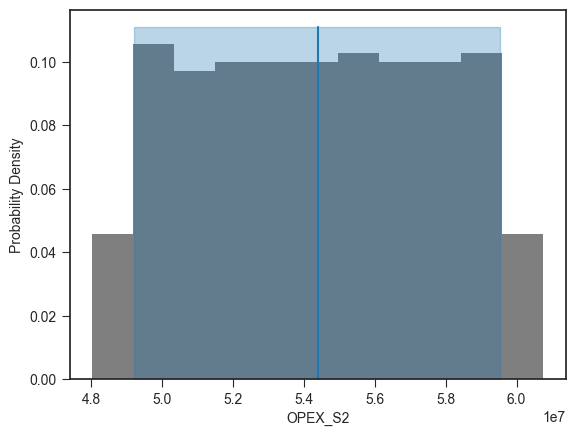

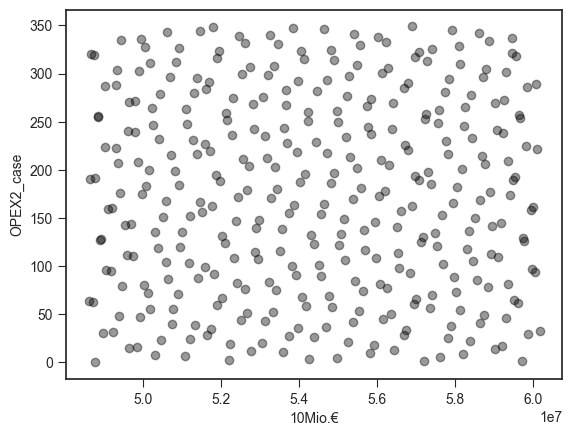

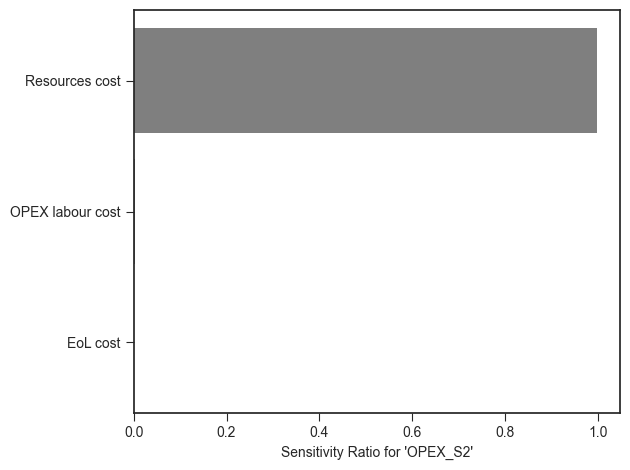

In [52]:
# Monaco OPEX S2 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(op_cost, op_labour, eol_cost):

       # run the opex simulation
       opr_cost = monte_opex(op_cost=op_cost, op_labour=op_labour, eol_cost=eol_cost)
       return (opr_cost, )


# Rename the y-aixs in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    op_cost = case.invals['Resources cost'].val
    op_labour = case.invals['OPEX labour cost'].val
    eol_cost = case.invals['EoL cost'].val

    return (op_cost, op_labour, eol_cost)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, opr_cost):
    case.addOutVal(name='OPEX_S2', val=opr_cost)
    case.addOutVal(name='OPEX2_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='OPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Resources cost', dist=uniform, distkwargs={'loc': 48500000, 'scale': 11580000})
sim.addInVar(name='OPEX labour cost', dist=uniform, distkwargs={'loc': 45000, 'scale': 10000})
sim.addInVar(name='EoL cost', dist=uniform, distkwargs={'loc': 50000, 'scale': 2000})


# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# statistics for the dice sum
sim.outvars['OPEX_S2'].addVarStat('mean')
sim.outvars['OPEX_S2'].addVarStat('percentile', {'p':[0.05, 0.95]})
# Plots a histogram of the dice sum
mc.plot(sim.outvars['OPEX_S2'])
# Creates a scatter plot of the sum vs the roll
# number, showing randomness
mc.plot(sim.outvars['OPEX_S2'],
sim.outvars['OPEX2_case'])

# add Mio.€ in
plt.xlabel('10Mio.€')

# Calculate the sensitivity of the dice sum to
# each of the input variables
sim.calcSensitivities('OPEX_S2')
sim.outvars['OPEX_S2'].plotSensitivities()

In [31]:
# If:
#    resource cost is incl. taxes;
#    depreciation cost is considered;
#    there is any recoverable taxes was taking into account.
# Then: 
#    Tax impacts

# Feed needed data in
#kwargs={
#        'equity' : 0.25, 
#        'eq_rate_return': 0.07,
#        'debt': 0.75, 
#        'db_intrst_rate': 0.045,
#        'inflation_rate' : 0.01,
#        }

# Extract resource_cost from OPEX
#resource_cost = df_global['Total Resources Price'].tolist()

#print(resource_cost)

#tax_impct = tax_impact(resource_cost=0, tax_rate=0.3, int_on_debt=0.045, depreciation=0, **kwargs)
#print(f"Tax Impact: {tax_impct:.2f}")

In [32]:
# Life Cycle Cost S1 - Total cost of ownership (TCO)
# with OPEX_S1_mean

# TCO S1 (Mean) is calculated here based on all the parameters listed below
lcc_S1_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_mean, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_mean:.2f}")

Life Cycle Cost: 72240409.32


In [33]:
# Life Cycle Cost S1 - Total cost of ownership
# with OPEX_S1_higher

# TCO S1 (High) is calculated here based on all the parameters listed below
lcc_S1_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_high, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_high:.2f}")

Life Cycle Cost: 82423357.93


In [34]:
# Life Cycle Cost S1 - Total cost of ownership
# with OPEX_S1_lower

# TCO S1 (Low) is calculated here based on all the parameters listed below
lcc_S1_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_low, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_low:.2f}")

Life Cycle Cost: 62193681.66


In [35]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_mean

# TCO S2 (Mean) is calculated here based on all the parameters listed below
lcc_S2_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_mean, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_mean:.2f}")

Life Cycle Cost: 56988401.22


In [36]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_higher

# TCO S2 (High) is calculated here based on all the parameters listed below
lcc_S2_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_high, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_high:.2f}")

Life Cycle Cost: 62554031.47


In [37]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_lower

# TCO S2 (Low) is calculated here based on all the parameters listed below
lcc_S2_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_low, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_low:.2f}")

Life Cycle Cost: 51469621.38


WARNING - (py.warnings._showwarnmsg) - c:\Users\yc20\projects\lcc_tools\.nvenv\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 62516 instead
  warnings.warn(



Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:62516/status
Running 'Life Cycle Cost of H2_wos' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:00.298714
Calculating sensitivity indices for 'TCO_S1'...
Calculating optimal hyperparameters Φ for 'TCO_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'TCO_S1'">)

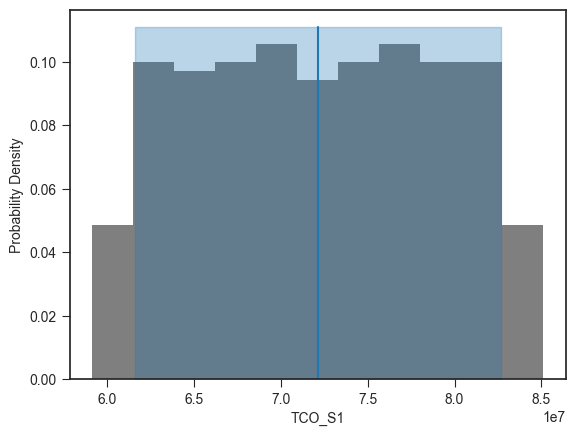

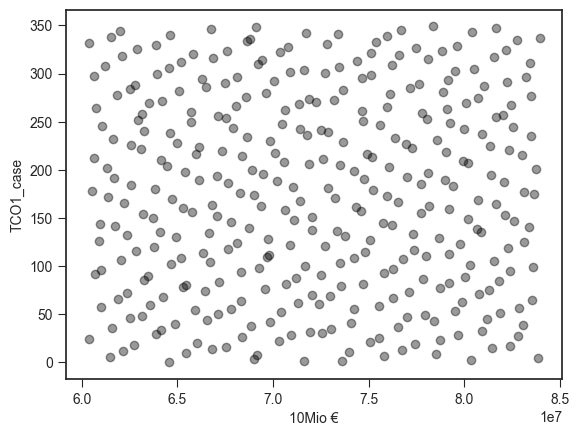

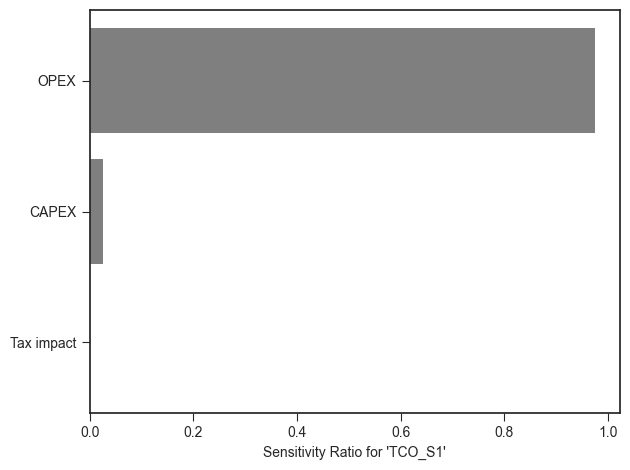

In [38]:
# Monaco TCO S1 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(investment_cost, opr_cost, tax_impact):

        # run the lcc simulation
        lcc_cost = monte_lcc(investment_cost=investment_cost, opr_cost=opr_cost, tax_impact=tax_impact)
        return (lcc_cost, )

 # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
def preprocess(case):
    investment_cost = case.invals['CAPEX'].val
    opr_cost = case.invals['OPEX'].val
    tax_impact = case. invals['Tax impact'].val

    return (investment_cost, opr_cost, tax_impact)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcc_cost):
    case.addOutVal(name='TCO_S1', val=lcc_cost)
    case.addOutVal(name='TCO1_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 # Arbitrary for this example
# Random seed for reproducibility
seed = 123456 # Recommended for repeatability
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='Life Cycle Cost of H2_wos', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='CAPEX', dist=uniform, distkwargs={'loc': 2200000, 'scale': 400000})
sim.addInVar(name='OPEX', dist=uniform, distkwargs={'loc': 58000000, 'scale': 23500000})
sim.addInVar(name='Tax impact', dist=uniform, distkwargs={'loc': 0, 'scale': 1})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['TCO_S1'].addVarStat('mean')
sim.outvars['TCO_S1'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['TCO_S1'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['TCO_S1'],
sim.outvars['TCO1_case'])
plt.xlabel('10Mio €')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('TCO_S1')
sim.outvars['TCO_S1'].plotSensitivities()

Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:8787/status
Running 'Life Cycle Cost of H2_wos' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:23.929965
Calculating sensitivity indices for 'TCO_S2'...
Calculating optimal hyperparameters Φ for 'TCO_S2' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'TCO_S2'">)

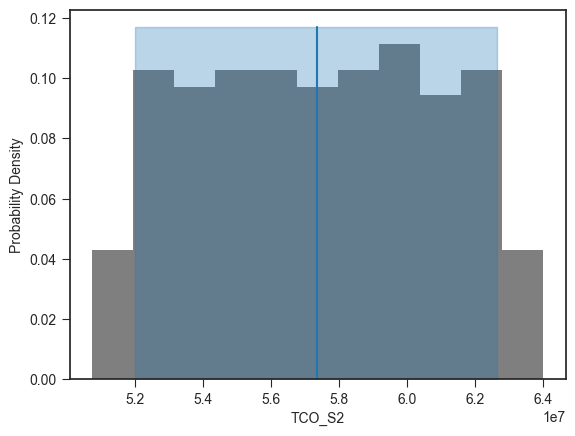

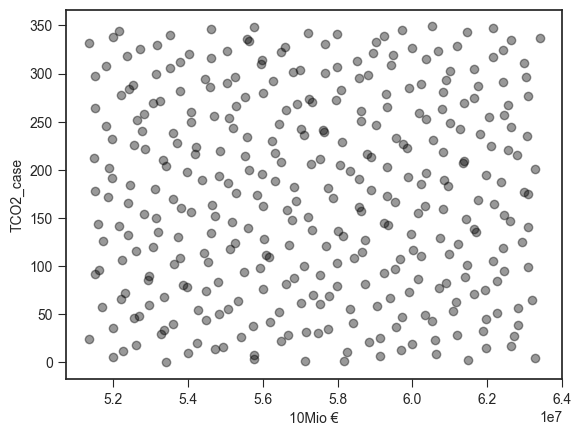

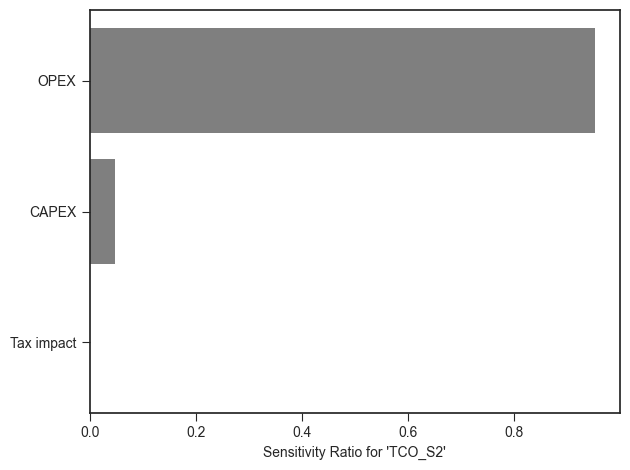

In [39]:
# Monaco TCO S2 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(investment_cost, opr_cost, tax_impact):

    # run the lcc simulation
    lcc_cost = monte_lcc(investment_cost=investment_cost, opr_cost=opr_cost, tax_impact=tax_impact)
    return (lcc_cost, )

# Rename the y-aixs in results
def preprocess(case):
    
    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    investment_cost = case.invals['CAPEX'].val
    opr_cost = case.invals['OPEX'].val
    tax_impact = case. invals['Tax impact'].val

    return (investment_cost, opr_cost, tax_impact)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcc_cost):
    case.addOutVal(name='TCO_S2', val=lcc_cost)
    case.addOutVal(name='TCO2_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 # Arbitrary for this example
# Random seed for reproducibility
seed = 123456 # Recommended for repeatability
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='Life Cycle Cost of H2_wos', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='CAPEX', dist=uniform, distkwargs={'loc': 2200000, 'scale': 400000})
sim.addInVar(name='OPEX', dist=uniform, distkwargs={'loc': 49000000, 'scale': 11900000})
sim.addInVar(name='Tax impact', dist=uniform, distkwargs={'loc': 0, 'scale': 1})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['TCO_S2'].addVarStat('mean')
sim.outvars['TCO_S2'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['TCO_S2'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['TCO_S2'],
sim.outvars['TCO2_case'])
plt.xlabel('10Mio €')

sim.calcSensitivities('TCO_S2')
sim.outvars['TCO_S2'].plotSensitivities()

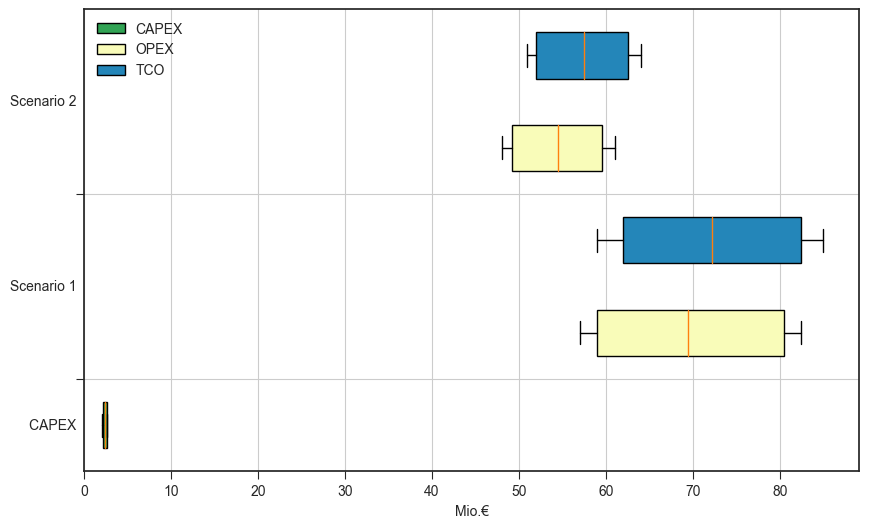

2024-05-12 21:00:10,559 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:63568', name: 1, status: running, memory: 87, processing: 0>
2024-05-12 21:00:10,893 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:63574', name: 3, status: running, memory: 90, processing: 3>
2024-05-12 21:00:13,949 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:63574'.
2024-05-12 21:00:13,956 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:63568'.


In [54]:
# Box plot - Results of CAPEX, OPEX and TCO - for manuscript

# Calcualted data from previous process
# p5 and p95 refer to the 5th and 95th percentiles respectively
# We use the p5 and p95 to plot a boxplot
capex = {'min': 2.098, 'max': 2.64, 'median': 2.36, 'p5': 2.14, 'p95': 2.58}
opex_s1 = {'min': 57, 'max': 82.5, 'median': 69.5, 'p5': 59, 'p95': 80.5}
opex_s2 = {'min': 48, 'max': 61, 'median': 54.5, 'p5': 49.2, 'p95': 59.5}
tco_s1 = {'min': 59, 'max': 85, 'median': 72.25, 'p5': 62, 'p95': 82.5}
tco_s2 = {'min': 50.9, 'max': 64, 'median': 57.5, 'p5': 52, 'p95': 62.5}

# Draw the boxplot
plt.figure(figsize=(10, 6))

# Plotting the boxplot using the data defined above
bp = plt.boxplot(
    [[capex['min'], capex['p5'], capex['median'], capex['p95'], capex['max']],
    [opex_s1['min'], opex_s1['p5'], opex_s1['median'], opex_s1['p95'], opex_s1['max']],
    [tco_s1['min'], tco_s1['p5'], tco_s1['median'], tco_s1['p95'], tco_s1['max']],
    [opex_s2['min'], opex_s2['p5'], opex_s2['median'], opex_s2['p95'], opex_s2['max']],
    [tco_s2['min'], tco_s2['p5'], tco_s2['median'], tco_s2['p95'], tco_s2['max']]],
            labels=['CAPEX', 'OPEX S1', 'TCO S1', 'OPEX S2', 'TCO S2'], vert=False, patch_artist=True)

# Set color
colors = [(49/255, 163/255, 84/255), (249/255, 252/255, 185/255), (36/255, 134/255, 185/255), (249/255, 252/255, 185/255), (36/255, 134/255, 185/255)]
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color)

legend_elements = [Patch(facecolor=(49/255, 163/255, 84/255), edgecolor='black', label='CAPEX'),
                   Patch(facecolor=(249/255, 252/255, 185/255), edgecolor='black', label='OPEX'),
                   Patch(facecolor=(36/255, 134/255, 185/255), edgecolor='black', label='TCO'),]

plt.legend(handles=legend_elements, loc='upper left')

# Define x-axis
plt.xlabel('Mio.€')

# Set y-axis
plt.xlim(0) 

plt.yticks([1.5, 3.5], ['', ''])

# Set lengend
plt.text(0, 1, 'CAPEX  ', ha='right', va='center')
plt.text(0, 2.5, 'Scenario 1  ', ha='right', va='center')
plt.text(0, 4.5, 'Scenario 2  ', ha='right', va='center')

# Print plot
plt.grid(True)
plt.show()


In [41]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_mean

# LCC S1 (Mean) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_mean = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S1_mean, h2_production=17796460, **kwargs)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_mean:.2f}")

In [42]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_higher

# LCC S1 (High) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_high = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S1_high, h2_production=17796460, **kwargs)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_high:.2f}")

In [43]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_low

# LCC S1 (Low) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_low = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S1_low, h2_production=17796460, **kwargs)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_low:.2f}")

In [44]:
# LCOH S2
# with LCC_S2_mean

# LCC S2 (Mean) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_mean = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S2_mean, h2_production=17796460, **kwargs)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_mean:.2f}")

In [45]:
# LCOH S2
# with LCC_S2_higher

# LCC S2 (High) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_high = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S2_high, h2_production=17796460, **kwargs)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_high:.2f}")

In [46]:
# LCOH S2
# with LCC_S2_lower

# LCC S2 (Low) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_low = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S2_low, h2_production=17796460, **kwargs)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_low:.2f}")

WARNING - (py.warnings._showwarnmsg) - c:\Users\yc20\projects\lcc_tools\.nvenv\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 62633 instead
  warnings.warn(



Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:62633/status
Running 'LCOH' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 7 input variables via the 'sobol' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:00.699129
Calculating sensitivity indices for 'LCOH_S1'...
Calculating optimal hyperparameters Φ for 'LCOH_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'LCOH_S1'">)

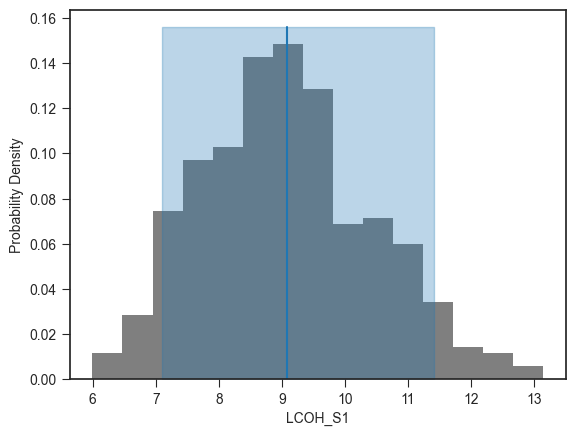

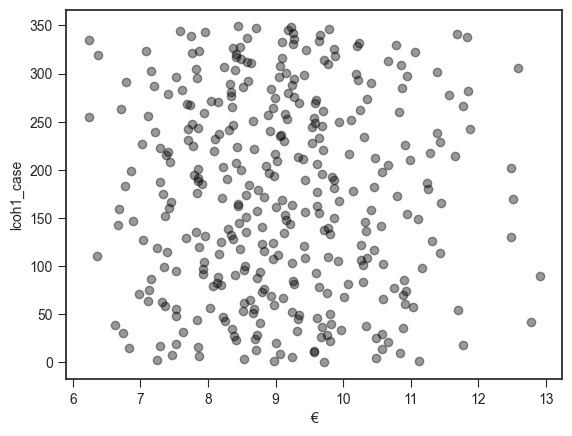

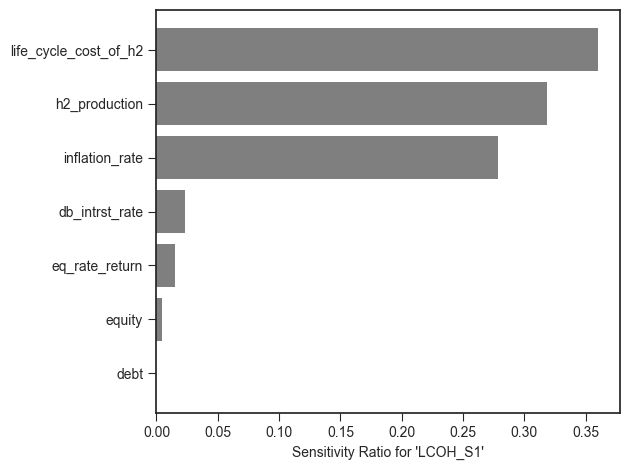

In [47]:
# Monaco LCOH S1 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate):
    kwargs={
        'inflation_rate' : inflation_rate,
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        }

    # run the lcoh simulation
    lcoh_cost = levelized_cost_of_h2(life_cycle_cost_of_h2=life_cycle_cost_of_h2, h2_production=h2_production, **kwargs)
    return (lcoh_cost, )

# The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
# Preprocess function for extracting usable variables from input dataframes
def preprocess(case):
    life_cycle_cost_of_h2 = case.invals['life_cycle_cost_of_h2'].val
    h2_production = case.invals['h2_production'].val
    equity = case.invals['equity'].val
    eq_rate_return = case.invals['eq_rate_return'].val
    debt = case.invals['debt'].val
    db_intrst_rate = case.invals['db_intrst_rate'].val
    inflation_rate = case.invals['inflation_rate'].val

    return (life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcoh_cost):
    case.addOutVal(name='LCOH_S1', val=lcoh_cost)
    case.addOutVal(name='lcoh1_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350
# Random seed for reproducibility
seed = 123456   # Recommanded for repeatability
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='LCOH', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='life_cycle_cost_of_h2', dist=uniform, distkwargs={'loc': 61000000, 'scale': 25000000})
sim.addInVar(name='inflation_rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.05})
sim.addInVar(name='h2_production', dist=uniform, distkwargs={'loc': 15000000, 'scale': 5000000}) 
sim.addInVar(name='equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.10})
sim.addInVar(name='eq_rate_return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='db_intrst_rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.005})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['LCOH_S1'].addVarStat('mean')
sim.outvars['LCOH_S1'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['LCOH_S1'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['LCOH_S1'],
sim.outvars['lcoh1_case'])
plt.xlabel('€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('LCOH_S1')
sim.outvars['LCOH_S1'].plotSensitivities()

Dask cluster initiated with 4 workers, 8 threads, 7.86 GiB memory.
Dask dashboard link: http://127.0.0.1:8787/status
Running 'LCOH' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 7 input variables via the 'sobol' method... Done
Generating cases... Done


Preprocessing, running, and postprocessing cases:   0%|          | 0/1050 [00:00<?, ? cases/s]

Simulation complete! Runtime: 0:00:33.155383
Calculating sensitivity indices for 'LCOH_S2'...
Calculating optimal hyperparameters Φ for 'LCOH_S2' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'LCOH_S2'">)

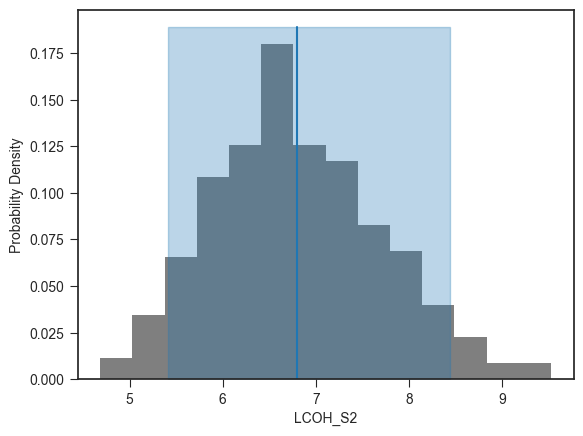

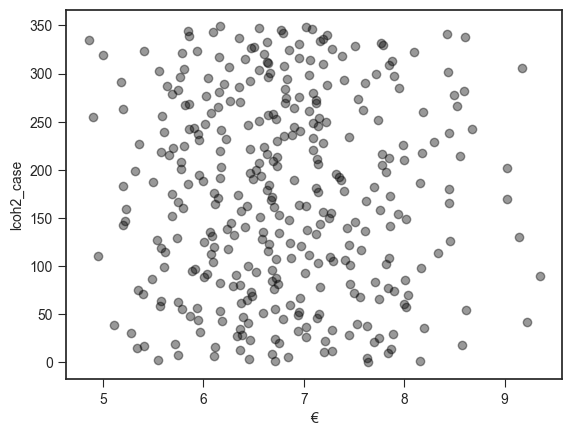

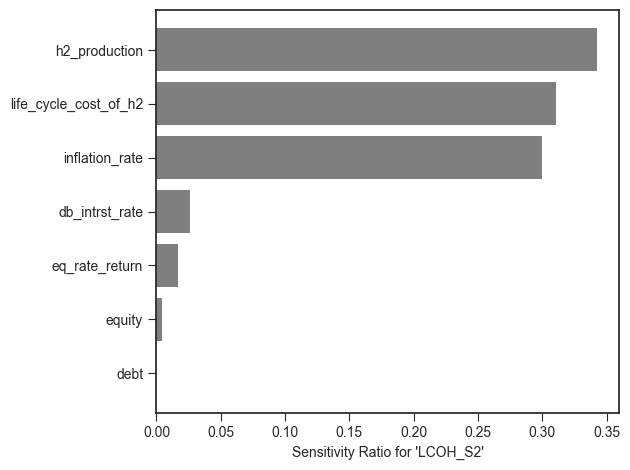

In [48]:
# Monaco LCOH S2 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate):
    
    # variables used within the LCOH function (utils.py)
    kwargs={
        'inflation_rate' : inflation_rate,
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        }
    
    # run the lcoh simulation
    lcoh_cost = levelized_cost_of_h2(life_cycle_cost_of_h2=life_cycle_cost_of_h2, h2_production=h2_production, **kwargs)
    return (lcoh_cost, )

# The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
# Preprocess function for extracting usable variables from input dataframes
def preprocess(case):
    life_cycle_cost_of_h2 = case.invals['life_cycle_cost_of_h2'].val
    h2_production = case.invals['h2_production'].val
    equity = case.invals['equity'].val
    eq_rate_return = case.invals['eq_rate_return'].val
    debt = case.invals['debt'].val
    db_intrst_rate = case.invals['db_intrst_rate'].val
    inflation_rate = case.invals['inflation_rate'].val

    return (life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcoh_cost):
    case.addOutVal(name='LCOH_S2', val=lcoh_cost)
    case.addOutVal(name='lcoh2_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='LCOH', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol',
            singlethreaded=False,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='life_cycle_cost_of_h2', dist=uniform, distkwargs={'loc': 48000000, 'scale': 14000000})
sim.addInVar(name='inflation_rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.05})
sim.addInVar(name='h2_production', dist=uniform, distkwargs={'loc': 15000000, 'scale': 5000000}) 
sim.addInVar(name='equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.10})
sim.addInVar(name='eq_rate_return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='db_intrst_rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.005})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['LCOH_S2'].addVarStat('mean')
sim.outvars['LCOH_S2'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['LCOH_S2'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['LCOH_S2'],
sim.outvars['lcoh2_case'])
plt.xlabel('€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('LCOH_S2')
sim.outvars['LCOH_S2'].plotSensitivities()

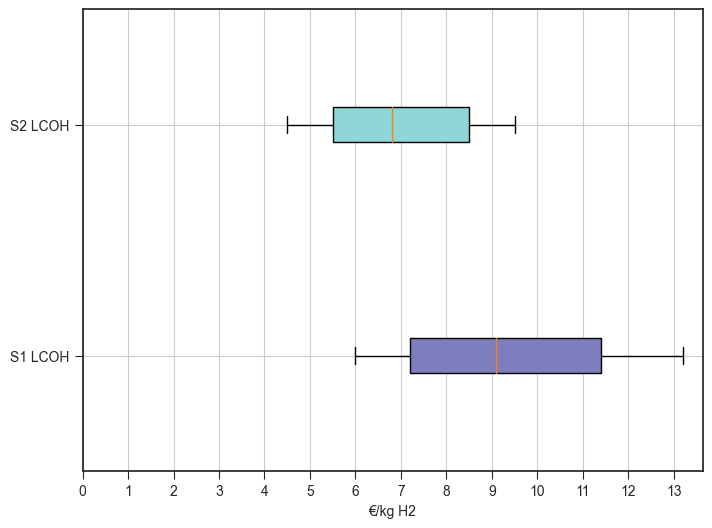

In [8]:
# Box plot - Results of LCOH in S1 and S2- for manuscript

# Calcualted data from previous process
# p5 and p95 refer to the 5th and 95th percentiles respectively
# we use the p5 and p95 to plot a boxplot
LCOH_s1 = {'min': 6, 'max': 13.2, 'median': 9.1, 'p5': 7.2, 'p95': 11.4}
LCOH_s2 = {'min': 4.5, 'max': 9.5, 'median': 6.8, 'p5': 5.5, 'p95': 8.5}

# Draw the boxplot
plt.figure(figsize=(8, 6))

# Plotting the boxplot using the data defined above
bp = plt.boxplot([[LCOH_s1['min'], LCOH_s1['p5'], LCOH_s1['median'], LCOH_s1['p95'], LCOH_s1['max']],
             [LCOH_s2['min'], LCOH_s2['p5'], LCOH_s2['median'], LCOH_s2['p95'], LCOH_s2['max']]],
            labels=['S1 LCOH', 'S2 LCOH'], vert=False, patch_artist=True)

# Set color
colors = [(125/255, 125/255, 190/255), (143/255, 215/255, 215/255)]
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color)

plt.xlabel('€/kg H2')

# Manually define the x-axis
plt.xticks(range(0, 14))

# Print plot
plt.grid(True)
plt.show()


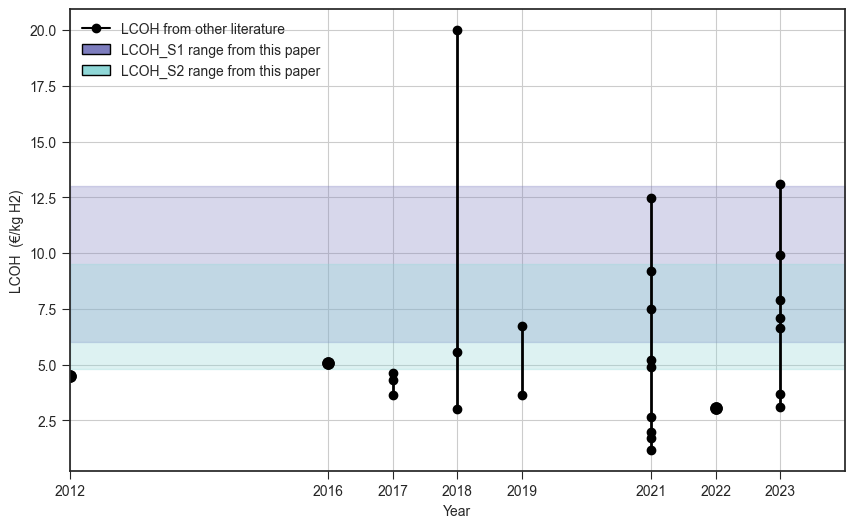

In [10]:
# Results validation - for manuscript

# Feed LCOH results from different literature
data = {
    "Year": [2012, 2016, 2017, 
             2018,
             2019, 
             2021,
             2022, 2023],
    "LCOH Literature": [[4.49], [5.07], [3.64, 4.31, 4.63], 
                        [3, 20, 5.55],
                        [3.64, 6.73], 
                        [2, 9.2, 12.48, 7.48, 5.19, 1.16, 4.9, 1.7, 2.67],
                        [3.07], [6.63, 7.11, 7.88, 3.7, 9.9, 3.08, 13.12]],
}

# Extract data from above
years = data['Year']
lcoh_data = data['LCOH Literature']

# Plot price intervals using line plot
plt.figure(figsize=(10, 6))

for year, lcoh in zip(years, lcoh_data):
    if len(lcoh) == 1:
        plt.plot([year, year], [lcoh[0], lcoh[0]], color='black', linewidth=2, marker='o', markersize=8, label=f'{year} LCOH: {lcoh[0]}')
    else:
        ymin = min(lcoh)
        ymax = max(lcoh)
        plt.plot([year, year], [ymin, ymax], color='black', linewidth=2, label=f'{year} LCOH: {ymin} - {ymax}')
        plt.scatter([year] * len(lcoh), lcoh, color='black', zorder=5)

# Add our LCOH range
plt.fill_between(range(2012, 2025), 6, 13, color=(125/255, 125/255, 190/255), alpha=0.3)
plt.fill_between(range(2012, 2025), 4.8, 9.5, color=(143/255, 215/255, 215/255), alpha=0.3)

# Set the range of the x-axis
plt.xlim(2012, 2024)

# Set labels for x-axis and y-axis
plt.xlabel('Year')
plt.ylabel('LCOH  (€/kg H2)')

# Define legend elements
legend_elements = [Line2D([0], [0], marker='o', color='black', label='LCOH from other literature', markersize=6),
                   Patch(facecolor=(125/255, 125/255, 190/255), edgecolor='black', label='LCOH_S1 range from this paper'),
                   Patch(facecolor=(143/255, 215/255, 215/255), edgecolor='black', label='LCOH_S2 range from this paper')]

# Add legend
plt.legend(handles=legend_elements, loc='upper left')

# Show plot
plt.grid(True)

# Remove 2014 from x-axis ticks
plt.gca().set_xticks([2012, 2016, 2017, 2018, 2019, 2021, 2022, 2023])

plt.show()
